In [4]:
import pulp

# 1. יצירת הבעיה - מקסום רווחים עבור המתחם המאוחד (חלק ב')
model = pulp.LpProblem("Global_Optimization_Cloud_Kitchen", pulp.LpMaximize)

# 2. הגדרת טווחי זמן (שעות הפעילות t)
hours = [10, 11, 12, 13, 14, 15]

# 3. מאגר הנתונים המדויק של כל המנות במתחם (רווח וזמן הכנה מתוך הדוח שלך)
items_data = {
    # מסעדת בשרוני
    'B_Burger':  {'name': 'המבורגר',     'profit': 50,  'prep_time': 13},
    'B_Steak':   {'name': 'סטייק',       'profit': 110, 'prep_time': 12},
    'B_Pargit':  {'name': 'פרגית',       'profit': 50,  'prep_time': 10},
    'B_Schnitzel':{'name': 'שניצל',      'profit': 45,  'prep_time': 10},
    'B_Liver':   {'name': 'כבד עוף',     'profit': 45,  'prep_time': 15},
    
    # מסעדת ויה איטליה
    'V_Margherita':{'name': 'מרגריטה',    'profit': 50,  'prep_time': 14},
    'V_ChefPizza': {'name': 'פיצה שף',    'profit': 75,  'prep_time': 19},
    'V_Tomato':    {'name': 'פסטה עגבניות','profit': 45,  'prep_time': 11},
    'V_Cream':     {'name': 'פסטה שמנת',  'profit': 50,  'prep_time': 15},
    
    # מסעדת הירוקה
    'H_CustomSalad':{'name': 'סלט בהרכבה','profit': 35,  'prep_time': 8},
    'H_Quinoa':    {'name': 'סלט קינואה', 'profit': 40,  'prep_time': 12},
    'H_Majadra':   {'name': 'מג`דרה',     'profit': 35,  'prep_time': 10},
    'H_Soup':      {'name': 'מרק היום',   'profit': 35,  'prep_time': 11}
}

# 4. חסמי הביקוש היומי הממוצע (הערכים המעוגלים מתוך הדוח שלך)
daily_demand_bounds = {
    'B_Burger': 20, 'B_Steak': 10, 'B_Pargit': 13, 'B_Schnitzel': 16, 'B_Liver': 7,
    'V_Margherita': 23, 'V_ChefPizza': 10, 'V_Tomato': 16, 'V_Cream': 17,
    'H_CustomSalad': 22, 'H_Quinoa': 11, 'H_Majadra': 16, 'H_Soup': 16
}

# 5. הגדרת משתני ההחלטה
# X[i, t] - כמות מנות i בשעה t (משתנה שלם וחיובי)
X = pulp.LpVariable.dicts("X", ((i, t) for i in items_data for t in hours), lowBound=0, cat='Integer')

# Y[t] - מספר העובדים הנוספים שנשכרו בשעה t (משתנה שלם וחיובי)
Y = pulp.LpVariable.dicts("Y", hours, lowBound=0, cat='Integer')

# 6. פונקציית המטרה: מקסום סך רווחי המנות פחות עלות העובדים הנוספים (60 ש"ח לשעה)
total_food_profit = pulp.lpSum([items_data[i]['profit'] * X[i, t] for i in items_data for t in hours])
total_labor_cost = pulp.lpSum([60 * Y[t] for t in hours])

model += total_food_profit - total_labor_cost

# 7. הגדרת האילוצים למערכת המשותפת
# אילוץ 1: חסם שוק - סך הייצור היומי של כל מנה לא יעלה על הביקוש היומי הממוצע
for i in items_data:
    model += pulp.lpSum([X[i, t] for t in hours]) <= daily_demand_bounds[i]

for t in hours:
    # אילוץ 2: מגבלת עמדות מטבח פיזיות בשעה t (מקסימום 6 עמדות פנויות = 360 דקות עמדה)
    model += pulp.lpSum([items_data[i]['prep_time'] * X[i, t] for i in items_data]) <= 360
    
    # אילוץ 3: מגבלת כוח אדם דינמית בשעה t
    # 6 עובדי הבסיס נותנים 360 דקות, וכל עובד נוסף (Y) מוסיף עוד 60 דקות בשעה זו
    model += pulp.lpSum([items_data[i]['prep_time'] * X[i, t] for i in items_data]) <= 360 + (60 * Y[t])

# אילוץ 4: מגבלת שעות עבודה נוספות כוללת למתחם (לפי הגדרות חלק ב' - בד"כ מכפילים את המכסה או משאירים גמיש)
# נגדיר חסם עליון הגיוני לשעות הנוספות הכוללות ביום (למשל מקסימום 12 שעות נוספות סך הכל לכל המתחם ביום)
model += pulp.lpSum([Y[t] for t in hours]) <= 12

# 8. הרצת המודל ופתרון
status = model.solve()

# 9. הדפסת השורה התחתונה של התוצאות
print(f"סטטוס הפתרון: {pulp.LpStatus[status]}")
print(f"סך הרווח היומי המאוחד של המתחם כולו (חלק ב'): {pulp.value(model.objective):,.2f} ₪")

סטטוס הפתרון: Optimal
סך הרווח היומי המאוחד של המתחם כולו (חלק ב'): 8,955.00 ₪


In [5]:
import pulp

# 1. הגדרת יצירת הבעיה - מקסום רווח כולל למתחם
model = pulp.LpProblem("Global_Kitchen_Optimization", pulp.LpMaximize)

# שעות הפעילות של המתחם
hours = [10, 11, 12, 13, 14, 15]

# 2. הגדרת נתוני המנות (שם מסעדה, שם מנה, רווח, זמן הכנה, חסם ביקוש יומי)
# המנות מסודרות וממוינות כאן בדיוק לפי רשימת המנות העדכנית שלך
dishes_data = {
    # מסעדת בשרוני
    1:  {"restaurant": "בשרוני", "name": "המבורגר", "profit": 50, "time": 13, "demand": 20},
    2:  {"restaurant": "בשרוני", "name": "סטייק", "profit": 110, "time": 12, "demand": 10},
    3:  {"restaurant": "בשרוני", "name": "פרגית", "profit": 50, "time": 10, "demand": 13},
    4:  {"restaurant": "בשרוני", "name": "שניצל", "profit": 45, "time": 10, "demand": 16},
    5:  {"restaurant": "בשרוני", "name": "כבד עוף", "profit": 45, "time": 15, "demand": 7},
    
    # מסעדת ויה איטלי
    6:  {"restaurant": "ויה איטלי", "name": "פיצה", "profit": 66, "time": 14, "demand": 17},
    7:  {"restaurant": "ויה איטלי", "name": "פסטה", "profit": 40, "time": 7, "demand": 14},
    8:  {"restaurant": "ויה איטלי", "name": "רביולי", "profit": 65, "time": 9, "demand": 11},
    9:  {"restaurant": "ויה איטלי", "name": "ניוקי", "profit": 57, "time": 9, "demand": 9},
    10: {"restaurant": "ויה איטלי", "name": "ריזוטו", "profit": 48, "time": 8, "demand": 6},
    
    # מסעדת הירוקה
    11: {"restaurant": "הירוקה", "name": "סלט הבית", "profit": 66, "time": 5, "demand": 17},
    12: {"restaurant": "הירוקה", "name": "מג'דרה", "profit": 40, "time": 7, "demand": 17},
    13: {"restaurant": "הירוקה", "name": "סלט קינואה", "profit": 65, "time": 7, "demand": 17},
    14: {"restaurant": "הירוקה", "name": "סלט אישי", "profit": 57, "time": 6, "demand": 17}
}

# 3. הגדרת משתני ההחלטה
# X[i, t] - כמות המנות מסוג i המיוצרות בשעה t (שלם חיובי)
X = pulp.LpVariable.dicts("X", 
                          ((i, t) for i in dishes_data.keys() for t in hours), 
                          lowBound=0, 
                          cat=pulp.LpInteger)

# Y[t] - משתנה בינארי לשכירת עובד נוסף בשעה t
Y = pulp.LpVariable.dicts("Y", hours, cat=pulp.LpBinary)

# 4. הגדרת פונקציית המטרה
# סך כל הרווחים מהמנות פחות עלות העסקת עובדים נוספים (60 ש"ח לכל שעה שבה Y=1)
model += pulp.lpSum(dishes_data[i]["profit"] * X[i, t] for i in dishes_data.keys() for t in hours) - \
         pulp.lpSum(60 * Y[t] for t in hours), "Total_Profit"

# 5. הגדרת מערכת האילוצים

# אילוץ 1: קיבולת כוח אדם וזמן מטבח שעתי משולב (לכל שעה בנפרד)
# 2 עובדי הבסיס נותנים 240 דקות בשעה. עובד נוסף מעניק עוד 120 דקות (תקרה של 360 דקות ל-6 עמדות)
for t in hours:
    model += pulp.lpSum(dishes_data[i]["time"] * X[i, t] for i in dishes_data.keys()) <= 240 + 120 * Y[t], f"Kitchen_Capacity_Hour_{t}"

# אילוץ 2: חסם שוק (מגבלת ביקוש יומי ממוצע לכל מנה בנפרד)
for i in dishes_data.keys():
    dish_name = dishes_data[i]["name"]
    res_name = dishes_data[i]["restaurant"]
    model += pulp.lpSum(X[i, t] for t in hours) <= dishes_data[i]["demand"], f"Demand_Limit_{res_name}_{dish_name}"

# 6. הרצת המודל ופתרון הבעיה
status = model.solve()

# 7. הדפסת התוצאות בצורה מסודרת לדו"ח שלך
print(f"סטטוס הפתרון: {pulp.LpStatus[status]}")
print(f"הרווח המקסימלי היומי הכולל של המתחם המאוחד: {pulp.value(model.objective):,.2f} ש''ח")
print("\n" + "="*50 + "\nתוכנית ייצור ושיבוץ עובדים מומלצת:\n" + "="*50)

for t in hours:
    print(f"\n--- שעה {t}:00 ---")
    if Y[t].varValue == 1:
        print("💡 [בשעה זו הועסק עובד נוסף בעלות של 60 ש''ח - קיבולת מלאה של 360 דקות]")
    else:
        print("👥 [שעה זו מופעלת על ידי 2 עובדי הבסיס בלבד - קיבולת של 240 דקות]")
    
    total_minutes_used = 0
    print("מנות להכנה בשעה זו:")
    for i in dishes_data.keys():
        if X[i, t].varValue > 0:
            qty = int(X[i, t].varValue)
            duration = dishes_data[i]["time"] * qty
            total_minutes_used += duration
            print(f"  <- מסעדת {dishes_data[i]['restaurant']}: {dishes_data[i]['name']} - כמות: {qty} מנות (זמן הכנה כולל: {duration} דקות)")
            
    print(f"סך הכל דקות ייצור מנוצלות בשעה זו: {total_minutes_used} דקות.")

print("\n" + "="*50 + "\nסיכום כמויות ייצור יומיות מול חסם הביקוש:\n" + "="*50)
for i in dishes_data.keys():
    total_made = sum(X[i, t].varValue for t in hours)
    print(f"מסעדת {dishes_data[i]['restaurant']} | {dishes_data[i]['name']}: יוצרו {int(total_made)} מנות מתוך ביקוש של {dishes_data[i]['demand']}")

סטטוס הפתרון: Optimal
הרווח המקסימלי היומי הכולל של המתחם המאוחד: 10,679.00 ש''ח

תוכנית ייצור ושיבוץ עובדים מומלצת:

--- שעה 10:00 ---
💡 [בשעה זו הועסק עובד נוסף בעלות של 60 ש''ח - קיבולת מלאה של 360 דקות]
מנות להכנה בשעה זו:
  <- מסעדת בשרוני: סטייק - כמות: 7 מנות (זמן הכנה כולל: 84 דקות)
  <- מסעדת בשרוני: פרגית - כמות: 13 מנות (זמן הכנה כולל: 130 דקות)
  <- מסעדת בשרוני: כבד עוף - כמות: 6 מנות (זמן הכנה כולל: 90 דקות)
  <- מסעדת ויה איטלי: ריזוטו - כמות: 6 מנות (זמן הכנה כולל: 48 דקות)
  <- מסעדת הירוקה: סלט הבית - כמות: 1 מנות (זמן הכנה כולל: 5 דקות)
סך הכל דקות ייצור מנוצלות בשעה זו: 357 דקות.

--- שעה 11:00 ---
👥 [שעה זו מופעלת על ידי 2 עובדי הבסיס בלבד - קיבולת של 240 דקות]
מנות להכנה בשעה זו:
  <- מסעדת בשרוני: המבורגר - כמות: 16 מנות (זמן הכנה כולל: 208 דקות)
  <- מסעדת הירוקה: סלט הבית - כמות: 6 מנות (זמן הכנה כולל: 30 דקות)
סך הכל דקות ייצור מנוצלות בשעה זו: 238 דקות.

--- שעה 12:00 ---
👥 [שעה זו מופעלת על ידי 2 עובדי הבסיס בלבד - קיבולת של 240 דקות]
מנות להכנה בשעה זו:
  <

In [8]:
import pandas as pd

# 1. הגדרת נתוני המנות מכל שלוש המסעדות במבנה נתונים מסודר
data = [
    # מסעדת בשרוני
    {"מסעדה": "בשרוני", "מנה": "המבורגר", "רווח למנה (שח)": 50, "זמן הכנה (דקות)": 13},
    {"מסעדה": "בשרוני", "מנה": "סטייק", "רווח למנה (שח)": 110, "זמן הכנה (דקות)": 12},
    {"מסעדה": "בשרוני", "מנה": "פרגית", "רווח למנה (שח)": 50, "זמן הכנה (דקות)": 10},
    {"מסעדה": "בשרוני", "מנה": "שניצל", "רווח למנה (שח)": 45, "זמן הכנה (דקות)": 10},
    {"מסעדה": "בשרוני", "מנה": "כבד עוף", "רווח למנה (שח)": 45, "זמן הכנה (דקות)": 15},
    
    # מסעדת ויה איטלי
    {"מסעדה": "ויה איטלי", "מנה": "פיצה", "רווח למנה (שח)": 66, "זמן הכנה (דקות)": 14},
    {"מסעדה": "ויה איטלי", "מנה": "פסטה", "רווח למנה (שח)": 40, "זמן הכנה (דקות)": 7},
    {"מסעדה": "ויה איטלי", "מנה": "רביולי", "רווח למנה (שח)": 65, "זמן הכנה (דקות)": 9},
    {"מסעדה": "ויה איטלי", "מנה": "ניוקי", "רווח למנה (שח)": 57, "זמן הכנה (דקות)": 9},
    {"מסעדה": "ויה איטלי", "מנה": "ריזוטו", "רווח למנה (שח)": 48, "זמן הכנה (דקות)": 8},
    
    # מסעדת הירוקה
    {"מסעדה": "הירוקה", "מנה": "סלט הבית", "רווח למנה (שח)": 66, "זמן הכנה (דקות)": 5},
    {"מסעדה": "הירוקה", "מנה": "מג'דרה", "רווח למנה (שח)": 40, "זמן הכנה (דקות)": 7},
    {"מסעדה": "הירוקה", "מנה": "סלט קינואה", "רווח למנה (שח)": 65, "זמן הכנה (דקות)": 7},
    {"מסעדה": "הירוקה", "מנה": "סלט אישי", "רווח למנה (שח)": 57, "זמן הכנה (דקות)": 6}
]

# 2. יצירת DataFrame (טבלה) מתוך הנתונים
df = pd.DataFrame(data)

# 3. חישוב מדד היעילות התפעולית: רווח לכל דקת ייצור
df["רווח לדקת ייצור (שח)"] = df["רווח למנה (שח)"] / df["זמן הכנה (דקות)"]

# 4. מיון הטבלה מהגדול לקטן על פי הרווח לדקה
df_sorted = df.sort_values(by="רווח לדקת ייצור (שח)", ascending=False).reset_index(drop=True)

# 5. הוספת עמודת דירוג ברורה (1 עד 14)
df_sorted.index = df_sorted.index + 1
df_sorted.index.name = "מיקום במיון"

# עיגול התוצאות ל-2 ספרות אחרי הנקודה לטובת נראות בדו"ח
df_sorted["רווח לדקת ייצור (שח)"] = df_sorted["רווח לדקת ייצור (שח)"].round(2)

# 6. הצגת הטבלה הממוינת הסופית
df_sorted

,מסעדה,מנה,רווח למנה (שח),זמן הכנה (דקות),רווח לדקת ייצור (שח)
מיקום במיון,,,,,
1,הירוקה,סלט הבית,66,5,13.20
2,הירוקה,סלט אישי,57,6,9.50
3,הירוקה,סלט קינואה,65,7,9.29
4,בשרוני,סטייק,110,12,9.17
5,ויה איטלי,רביולי,65,9,7.22
6,ויה איטלי,ניוקי,57,9,6.33
7,ויה איטלי,ריזוטו,48,8,6.00
8,ויה איטלי,פסטה,40,7,5.71
9,הירוקה,מג'דרה,40,7,5.71


In [9]:
import pandas as pd

# 1. הגדרת נתוני המנות המעודכנים
data = [
    {"מסעדה": "בשרוני", "מנה": "המבורגר", "רווח למנה (שח)": 50, "זמן הכנה (דקות)": 13},
    {"מסעדה": "בשרוני", "מנה": "סטייק", "רווח למנה (שח)": 110, "זמן הכנה (דקות)": 12},
    {"מסעדה": "בשרוני", "מנה": "פרגית", "רווח למנה (שח)": 50, "זמן הכנה (דקות)": 10},
    {"מסעדה": "בשרוני", "מנה": "שניצל", "רווח למנה (שח)": 45, "זמן הכנה (דקות)": 10},
    {"מסעדה": "בשרוני", "מנה": "כבד עוף", "רווח למנה (שח)": 45, "זמן הכנה (דקות)": 15},
    
    {"מסעדה": "ויה איטלי", "מנה": "פיצה", "רווח למנה (שח)": 66, "זמן הכנה (דקות)": 14},
    {"מסעדה": "ויה איטלי", "מנה": "פסטה", "רווח למנה (שח)": 40, "זמן הכנה (דקות)": 7},
    {"מסעדה": "ויה איטלי", "מנה": "רביולי", "רווח למנה (שח)": 65, "זמן הכנה (דקות)": 9},
    {"מסעדה": "ויה איטלי", "מנה": "ניוקי", "רווח למנה (שח)": 57, "זמן הכנה (דקות)": 9},
    {"מסעדה": "ויה איטלי", "מנה": "ריזוטו", "רווח למנה (שח)": 48, "זמן הכנה (דקות)": 8},
    
    {"מסעדה": "הירוקה", "מנה": "סלט הבית", "רווח למנה (שח)": 66, "זמן הכנה (דקות)": 5},
    {"מסעדה": "הירוקה", "מנה": "מג'דרה", "רווח למנה (שח)": 40, "זמן הכנה (דקות)": 7},
    {"מסעדה": "הירוקה", "מנה": "סלט קינואה", "רווח למנה (שח)": 65, "זמן הכנה (דקות)": 7},
    {"מסעדה": "הירוקה", "מנה": "סלט אישי", "רווח למנה (שח)": 57, "זמן הכנה (דקות)": 6}
]

# 2. יצירת ה-DataFrame וחישוב מדד היעילות
df = pd.DataFrame(data)
df["רווח לדקת ייצור (שח)"] = df["רווח למנה (שח)"] / df["זמן הכנה (דקות)"]

# 3. מיון מהגדול לקטן ואיפוס האינדקס
df_sorted = df.sort_values(by="רווח לדקת ייצור (שח)", ascending=False).reset_index(drop=True)
df_sorted.index = df_sorted.index + 1
df_sorted.index.name = "דירוג"

# 4. עיצוב מתקדם ומקצועי של הטבלה להצגה
styled_df = df_sorted.style.format({
    "רווח למנה (שח)": "{:,.0f} ₪",
    "זמן הכנה (דקות)": "{} דק'",
    "רווח לדקת ייצור (שח)": "{:.2f} ₪"
}).set_properties(**{
    'text-align': 'center',              # יישור כל הנתונים למרכז
    'font-family': 'Segoe UI, Arial',   # פונט נקי ומקצועי
    'padding': '10px'                    # מרווח נשימה פנימי בתאים
}).set_table_styles([
    # עיצוב שורת הכותרת (צבע כחול-אפור כהה, טקסט לבן מודגש)
    {'selector': 'th', 'props': [
        ('background-color', '#2c3e50'), 
        ('color', 'white'), 
        ('font-weight', 'bold'),
        ('text-align', 'center'),
        ('border', '1px solid #bdc3c7')
    ]},
    # עיצוב הגבולות של תאי הנתונים
    {'selector': 'td', 'props': [
        ('border', '1px solid #e2e8f0')
    ]}
]).background_gradient(
    subset=["רווח לדקת ייצור (שח)"], 
    cmap="Blues", # צביעה הדרגתית עדינה בגווני כחול למדד המוביל
    high=0.3      # ויסות הכהות של הצבע כדי להישאר סולידי ונקי
)

# הצגת הטבלה המעוצבת
styled_df

,מסעדה,מנה,רווח למנה (שח),זמן הכנה (דקות),רווח לדקת ייצור (שח)
דירוג,,,,,
1,הירוקה,סלט הבית,66 ₪,5 דק',13.20 ₪
2,הירוקה,סלט אישי,57 ₪,6 דק',9.50 ₪
3,הירוקה,סלט קינואה,65 ₪,7 דק',9.29 ₪
4,בשרוני,סטייק,110 ₪,12 דק',9.17 ₪
5,ויה איטלי,רביולי,65 ₪,9 דק',7.22 ₪
6,ויה איטלי,ניוקי,57 ₪,9 דק',6.33 ₪
7,ויה איטלי,ריזוטו,48 ₪,8 דק',6.00 ₪
8,ויה איטלי,פסטה,40 ₪,7 דק',5.71 ₪
9,הירוקה,מג'דרה,40 ₪,7 דק',5.71 ₪


In [11]:
import pandas as pd

# 1. הגדרת נתוני המנות המעודכנים מכל שלוש המסעדות
data = [
    # מסעדת בשרוני
    {"מסעדה": "בשרוני", "מנה": "המבורגר", "רווח למנה (שח)": 50, "זמן הכנה (דקות)": 13},
    {"מסעדה": "בשרוני", "מנה": "סטייק", "רווח למנה (שח)": 110, "זמן הכנה (דקות)": 12},
    {"מסעדה": "בשרוני", "מנה": "פרגית", "רווח למנה (שח)": 50, "זמן הכנה (דקות)": 10},
    {"מסעדה": "בשרוני", "מנה": "שניצל", "רווח למנה (שח)": 45, "זמן הכנה (דקות)": 10},
    {"מסעדה": "בשרוני", "מנה": "כבד עוף", "רווח למנה (שח)": 45, "זמן הכנה (דקות)": 15},
    
    # מסעדת ויה איטלי
    {"מסעדה": "ויה איטלי", "מנה": "פיצה", "רווח למנה (שח)": 66, "זמן הכנה (דקות)": 14},
    {"מסעדה": "ויה איטלי", "מנה": "פסטה", "רווח למנה (שח)": 40, "זמן הכנה (דקות)": 7},
    {"מסעדה": "ויה איטלי", "מנה": "רביולי", "רווח למנה (שח)": 65, "זמן הכנה (דקות)": 9},
    {"מסעדה": "ויה איטלי", "מנה": "ניוקי", "רווח למנה (שח)": 57, "זמן הכנה (דקות)": 9},
    {"מסעדה": "ויה איטלי", "מנה": "ריזוטו", "רווח למנה (שח)": 48, "זמן הכנה (דקות)": 8},
    
    # מסעדת הירוקה
    {"מסעדה": "הירוקה", "מנה": "סלט הבית", "רווח למנה (שח)": 66, "זמן הכנה (דקות)": 5},
    {"מסעדה": "הירוקה", "מנה": "מג'דרה", "רווח למנה (שח)": 40, "זמן הכנה (דקות)": 7},
    {"מסעדה": "הירוקה", "מנה": "סלט קינואה", "רווח למנה (שח)": 65, "זמן הכנה (דקות)": 7},
    {"מסעדה": "הירוקה", "מנה": "סלט אישי", "רווח למנה (שח)": 57, "זמן הכנה (דקות)": 6}
]

# 2. יצירת ה-DataFrame וחישוב עמודת הרווח לדקה
df = pd.DataFrame(data)
df["רווח לדקת ייצור (שח)"] = df["רווח למנה (שח)"] / df["זמן הכנה (דקות)"]

# 3. מיון הטבלה מהגדול לקטן על פי הרווח לדקה
df_sorted = df.sort_values(by="רווח לדקת ייצור (שח)", ascending=False).reset_index(drop=True)

# 4. הגדרת עמודת דירוג ברורה (1 עד 14) בתור ה-Index
df_sorted.index = df_sorted.index + 1
df_sorted.index.name = "מיקום במיוון"

# 5. החלת העיצוב: מראה ברירת המחדל הנקי, בתוספת צביעה הדרגתית לטור הרווח בלבד
styled_df = df_sorted.style.background_gradient(
    subset=["רווח לדקת ייצור (שח)"], 
    cmap="Blues", 
    high=0.3
).format({
    "רווח לדקת ייצור (שח)": "{:.2f}"  # הצגת 2 ספרות אחרי הנקודה בלבד בטור הצבוע
})

# 6. הצגת הטבלה המשולבת
styled_df

,מסעדה,מנה,רווח למנה (שח),זמן הכנה (דקות),רווח לדקת ייצור (שח)
מיקום במיוון,,,,,
1,הירוקה,סלט הבית,66,5,13.20
2,הירוקה,סלט אישי,57,6,9.50
3,הירוקה,סלט קינואה,65,7,9.29
4,בשרוני,סטייק,110,12,9.17
5,ויה איטלי,רביולי,65,9,7.22
6,ויה איטלי,ניוקי,57,9,6.33
7,ויה איטלי,ריזוטו,48,8,6.00
8,ויה איטלי,פסטה,40,7,5.71
9,הירוקה,מג'דרה,40,7,5.71


In [13]:
# התקנת ספרייה (אם צריך): pip install pulp
import pulp as pl

# -----------------------------
# נתונים
# -----------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

base_capacity = 120          # דקות לשעה
extra_capacity = 120         # תוספת עובד
extra_worker_cost = 60       # ש"ח לשעה

# -----------------------------
# מודל
# -----------------------------
model = pl.LpProblem("Restaurant_Optimization", pl.LpMaximize)

# משתני החלטה X_{dish,hour}
X = pl.LpVariable.dicts(
    "X",
    ((d, t) for d in dishes for t in hours),
    lowBound=0,
    cat="Continuous"
)

# משתני עובדים Y_t
Y = pl.LpVariable.dicts(
    "Y",
    (t for t in hours),
    lowBound=0,
    upBound=1,
    cat="Binary"
)

# -----------------------------
# פונקציית מטרה
# -----------------------------
model += (
    pl.lpSum(profit[d] * X[(d, t)] for d in dishes for t in hours)
    - extra_worker_cost * pl.lpSum(Y[t] for t in hours)
)

# -----------------------------
# אילוצי ביקוש
# -----------------------------
for d in dishes:
    model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d], f"demand_{d}"

# -----------------------------
# אילוצי קיבולת זמן לכל שעה
# -----------------------------
for t in hours:
    model += (
        pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes)
        <= base_capacity + extra_capacity * Y[t]
    ), f"capacity_{t}"

# -----------------------------
# פתרון
# -----------------------------
model.solve(pl.PULP_CBC_CMD(msg=0))

status = pl.LpStatus[model.status]
optimal_profit = pl.value(model.objective)

# -----------------------------
# חישוב עומסים, צווארי בקבוק ולוח עבודה
# -----------------------------
schedule = {t: {} for t in hours}
load_per_hour = {}
bottlenecks = []

for t in hours:
    # כמות מכל מנה בשעה t
    for d in dishes:
        qty = X[(d, t)].varValue
        if qty is None:
            qty = 0.0
        if qty > 1e-6:  # מציגים רק אם לא זניח
            schedule[t][d] = qty

    # עומס בדקות
    load = sum(prep_time[d] * X[(d, t)].varValue for d in dishes)
    load_per_hour[t] = load

    # קיבולת בפועל
    cap = base_capacity + extra_capacity * Y[t].varValue

    # צוואר בקבוק אם העומס קרוב מאוד לקיבולת (למשל 95%+)
    if cap > 0 and load >= 0.95 * cap:
        bottlenecks.append(t)

# -----------------------------
# הדפסה – פלט קריא
# -----------------------------
print("=" * 60)
print("סטטוס פתרון:", status)
print("=" * 60)
print(f"רווח גלובלי אופטימלי: {optimal_profit:,.0f} ₪")
print("=" * 60)
print("לוח עבודה לפי שעות (10:00–16:00)")
print("-" * 60)

for t in hours:
    print(f"\nשעה {t}:00–{t+1}:00")
    print(f"  עובד נוסף?  {'כן' if Y[t].varValue > 0.5 else 'לא'}")
    print("  מנות מיוצרות:")
    if not schedule[t]:
        print("    (אין ייצור בשעה זו)")
    else:
        for d, qty in sorted(schedule[t].items()):
            print(f"    {d:4s} : {qty:5.2f} יחידות")

    load = load_per_hour[t]
    cap = base_capacity + extra_capacity * Y[t].varValue
    utilization = (load / cap * 100) if cap > 0 else 0
    print(f"  עומס: {load:6.1f} דקות מתוך {cap:6.1f}  ({utilization:5.1f}%)")

print("\n" + "=" * 60)
print("זיהוי צווארי בקבוק")
print("-" * 60)
if bottlenecks:
    for t in bottlenecks:
        load = load_per_hour[t]
        cap = base_capacity + extra_capacity * Y[t].varValue
        print(f"שעה {t}:00–{t+1}:00 היא צוואר בקבוק (עומס {load:.1f} / קיבולת {cap:.1f})")
else:
    print("לא זוהו צווארי בקבוק (אין שעה עם עומס קרוב מאוד לקיבולת).")
print("=" * 60)


סטטוס פתרון: Optimal
רווח גלובלי אופטימלי: 9,342 ₪
לוח עבודה לפי שעות (10:00–16:00)
------------------------------------------------------------

שעה 10:00–11:00
  עובד נוסף?  כן
  מנות מיוצרות:
    BS   :  3.33 יחידות
    GM   : 17.00 יחידות
    VN   :  9.00 יחידות
  עומס:  240.0 דקות מתוך  240.0  (100.0%)

שעה 11:00–12:00
  עובד נוסף?  כן
  מנות מיוצרות:
    BH   :  3.15 יחידות
    BSh  :  1.90 יחידות
    GI   : 17.00 יחידות
    GQ   : 11.14 יחידות
  עומס:  240.0 דקות מתוך  240.0  (100.0%)

שעה 12:00–13:00
  עובד נוסף?  כן
  מנות מיוצרות:
    BP   : 10.70 יחידות
    GH   : 17.00 יחידות
    VZ   :  6.00 יחידות
  עומס:  240.0 דקות מתוך  240.0  (100.0%)

שעה 13:00–14:00
  עובד נוסף?  כן
  מנות מיוצרות:
    BSh  : 14.10 יחידות
    VR   : 11.00 יחידות
  עומס:  240.0 דקות מתוך  240.0  (100.0%)

שעה 14:00–15:00
  עובד נוסף?  כן
  מנות מיוצרות:
    BP   :  2.30 יחידות
    BS   :  6.67 יחידות
    GQ   :  5.86 יחידות
    VPst : 13.71 יחידות
  עומס:  240.0 דקות מתוך  240.0  (100.0%)

שעה 15:00–

In [14]:
# pip install pulp
import pulp as pl
import pandas as pd

# -----------------------------
# נתונים
# -----------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

base_capacity = 120
extra_capacity = 120
extra_worker_cost = 60

# -----------------------------
# מודל
# -----------------------------
model = pl.LpProblem("Restaurant_Optimization", pl.LpMaximize)

# משתני החלטה — שלמים
X = pl.LpVariable.dicts(
    "X",
    ((d, t) for d in dishes for t in hours),
    lowBound=0,
    cat="Integer"
)

Y = pl.LpVariable.dicts(
    "Y",
    (t for t in hours),
    lowBound=0,
    upBound=1,
    cat="Binary"
)

# -----------------------------
# פונקציית מטרה
# -----------------------------
model += (
    pl.lpSum(profit[d] * X[(d, t)] for d in dishes for t in hours)
    - extra_worker_cost * pl.lpSum(Y[t] for t in hours)
)

# -----------------------------
# אילוצי ביקוש
# -----------------------------
for d in dishes:
    model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

# -----------------------------
# אילוצי קיבולת זמן
# -----------------------------
for t in hours:
    model += (
        pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes)
        <= base_capacity + extra_capacity * Y[t]
    )

# -----------------------------
# פתרון
# -----------------------------
model.solve(pl.PULP_CBC_CMD(msg=0))

optimal_profit = pl.value(model.objective)

# -----------------------------
# בניית לוח עבודה + עומסים
# -----------------------------
rows = []
bottlenecks = []

for t in hours:
    load = sum(prep_time[d] * X[(d, t)].varValue for d in dishes)
    cap = base_capacity + extra_capacity * Y[t].varValue
    util = load / cap if cap > 0 else 0

    if util >= 0.95:
        bottlenecks.append(t)

    row = {
        "שעה": f"{t}:00–{t+1}:00",
        "עובד נוסף": "כן" if Y[t].varValue > 0.5 else "לא",
        "עומס (דקות)": round(load, 1),
        "קיבולת": int(cap),
        "ניצולת": f"{util*100:.1f}%"
    }

    for d in dishes:
        row[d] = int(X[(d, t)].varValue)

    rows.append(row)

schedule_df = pd.DataFrame(rows)

# -----------------------------
# הדפסה מקצועית
# -----------------------------
print("\n" + "="*80)
print("📌 רווח גלובלי אופטימלי:", f"{optimal_profit:,.0f} ₪")
print("="*80)

print("\n📋 לוח עבודה אופטימלי:")
print(schedule_df.to_string(index=False))

print("\n" + "="*80)
print("🔍 זיהוי צווארי בקבוק")
print("="*80)

if bottlenecks:
    for t in bottlenecks:
        print(f"שעה {t}:00–{t+1}:00 היא צוואר בקבוק (ניצולת ≥ 95%)")
else:
    print("לא זוהו צווארי בקבוק.")



📌 רווח גלובלי אופטימלי: 9,334 ₪

📋 לוח עבודה אופטימלי:
         שעה עובד נוסף  עומס (דקות)  קיבולת  ניצולת  BH  BS  BP  BSh  BL  VP  VPst  VR  VN  VZ  GH  GM  GQ  GI
 10:00–11:00        כן        240.0     240  100.0%   2   0   0    0   0   0     0   0   7   0   8  14   1   1
 11:00–12:00        כן        240.0     240  100.0%   1   0   0    5   0   0     5   0   0   2   0   2  16   0
 12:00–13:00        כן        240.0     240  100.0%   0   1   9    0   0   1     0   0   0   4   5   1   0  10
 13:00–14:00        כן        240.0     240  100.0%   0   0   1   11   0   0     0   8   2   0   0   0   0   5
 14:00–15:00        כן        240.0     240  100.0%   0   9   3    0   0   0     9   2   0   0   3   0   0   1
 15:00–16:00        כן        238.0     240   99.2%   0   0   0    0   0  16     0   1   0   0   1   0   0   0

🔍 זיהוי צווארי בקבוק
שעה 10:00–11:00 היא צוואר בקבוק (ניצולת ≥ 95%)
שעה 11:00–12:00 היא צוואר בקבוק (ניצולת ≥ 95%)
שעה 12:00–13:00 היא צוואר בקבוק (ניצולת ≥ 95%)
שעה 

In [15]:
# pip install pulp
import pulp as pl
import pandas as pd
from IPython.display import display, HTML

# -----------------------------
# נתונים
# -----------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

base_capacity = 240       # 2 עובדים * 2 מנות * 60 דקות = 240 דקות בסיס לשעה
extra_capacity = 120      # עובד 1 נוסף * 2 מנות * 60 דקות = 120 דקות תוספת לשעה
extra_worker_cost = 60

# -----------------------------
# מודל
# -----------------------------
model = pl.LpProblem("Restaurant_Optimization", pl.LpMaximize)

X = pl.LpVariable.dicts("X", ((d, t) for d in dishes for t in hours), lowBound=0, cat="Integer")
Y = pl.LpVariable.dicts("Y", (t for t in hours), lowBound=0, upBound=1, cat="Binary")

# פונקציית מטרה
model += (
    pl.lpSum(profit[d] * X[(d, t)] for d in dishes for t in hours)
    - extra_worker_cost * pl.lpSum(Y[t] for t in hours)
)

# אילוצי ביקוש
for d in dishes:
    model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

# אילוצי קיבולת זמן (תקרת 6 עמדות = 360 דקות)
for t in hours:
    model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes) <= base_capacity + extra_capacity * Y[t]

# פתרון
model.solve(pl.PULP_CBC_CMD(msg=0))
optimal_profit = pl.value(model.objective)

# -----------------------------
# בניית לוח עבודה + ניתוח מדדים
# -----------------------------
rows = []
bottlenecks = []

for t in hours:
    load = sum(prep_time[d] * X[(d, t)].varValue for d in dishes)
    cap = base_capacity + extra_capacity * Y[t].varValue
    util = load / cap if cap > 0 else 0

    if util >= 0.95:
        bottlenecks.append(f"{t}:00–{t+1}:00")

    row = {
        "שעה": f"{t}:00–{t+1}:00",
        "עובד נוסף": "כן" if Y[t].varValue > 0.5 else "לא",
        "עומס (דק')": int(load),
        "קיבולת (דק')": int(cap),
        "ניצולת": util  # נשמור כמספר עשרוני לצורך צביעה
    }

    for d in dishes:
        row[d] = int(X[(d, t)].varValue)

    rows.append(row)

schedule_df = pd.DataFrame(rows)

# -----------------------------
# הצגה ויזואלית מעוצבת ומקצועית
# -----------------------------

# 1. כותרת רווח אופטימלי נקייה ב-HTML
display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial; padding: 15px; background-color: #f8f9fa; border-right: 5px solid #2c3e50; margin-bottom: 20px;">
    <span style="font-size: 16px; color: #7f8c8d; display: block; font-weight: 500;">תוצאת האופטימיזציה הגלובלית:</span>
    <span style="font-size: 26px; color: #2c3e50; font-weight: bold;">💸 רווח כולל אופטימלי המתקבל: {optimal_profit:,.0f} ₪</span>
</div>
"""))

# 2. עיצוב לוח העבודה (שילוב המראה הנקי של Jupyter ודירוג כחול לטור הניצולת)
styled_schedule = schedule_df.style.background_gradient(
    subset=["ניצולת"], 
    cmap="Blues", 
    high=0.3
).format({
    "ניצולת": "{:.1%}" # הפיכת הניצולת לאחוזים רק בתצוגה
}).set_properties(**{
    'text-align': 'center'
})

print("📋 לוח עבודה ותוכנית ייצור שעתית:")
display(styled_schedule)

# 3. תצוגת צווארי בקבוק נקייה
display(HTML("<br>"))
if bottlenecks:
    bottleneck_list = ", ".join(bottlenecks)
    display(HTML(f"""
    <div style="font-family: 'Segoe UI', Arial; padding: 12px; background-color: #fff5f5; border-right: 5px solid #e74c3c; color: #c0392b;">
        <strong>⚠️ זיהוי צווארי בקבוק (ניצולת קיבולת ≥ 95%):</strong> השעות הבאות נמצאות בקיבולת מקסימלית: {bottleneck_list}
    </div>
    """))
else:
    display(HTML("""
    <div style="font-family: 'Segoe UI', Arial; padding: 12px; background-color: #f0fff4; border-right: 5px solid #2ecc71; color: #27ae60;">
        <strong>✅ זיהוי צווארי בקבוק:</strong> לא זוהו שעות קריטיות. הקיבולת מנוהלת בצורה מאוזנת על פני כל יום הפעילות.
    </div>
    """))

📋 לוח עבודה ותוכנית ייצור שעתית:


,שעה,עובד נוסף,עומס (דק'),קיבולת (דק'),ניצולת,BH,BS,BP,BSh,BL,VP,VPst,VR,VN,VZ,GH,GM,GQ,GI
0,10:00–11:00,כן,353,360,98.1%,0,4,0,0,7,0,0,0,9,0,0,17,0,0
1,11:00–12:00,כן,349,360,96.9%,19,0,0,0,0,0,0,0,0,0,0,0,0,17
2,12:00–13:00,לא,233,240,97.1%,1,0,6,0,0,0,0,3,0,6,17,0,0,0
3,13:00–14:00,לא,232,240,96.7%,0,0,0,16,0,0,0,8,0,0,0,0,0,0
4,14:00–15:00,כן,359,360,99.7%,0,6,7,0,0,0,14,0,0,0,0,0,17,0
5,15:00–16:00,לא,238,240,99.2%,0,0,0,0,0,17,0,0,0,0,0,0,0,0


In [16]:
# pip install pulp
import pulp as pl
import pandas as pd
from IPython.display import display, HTML

# -----------------------------
# נתונים
# -----------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

# מילון תרגום השמות המלאים לראשי העמודות בטבלה
dish_names = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

base_capacity = 240       # 2 עובדים * 2 מנות * 60 דקות = 240 דקות בסיס לשעה
extra_capacity = 120      # עובד 1 נוסף * 2 מנות * 60 דקות = 120 דקות תוספת לשעה
extra_worker_cost = 60

# -----------------------------
# מודל
# -----------------------------
model = pl.LpProblem("Restaurant_Optimization", pl.LpMaximize)

X = pl.LpVariable.dicts("X", ((d, t) for d in dishes for t in hours), lowBound=0, cat="Integer")
Y = pl.LpVariable.dicts("Y", (t for t in hours), lowBound=0, upBound=1, cat="Binary")

# פונקציית מטרה
model += (
    pl.lpSum(profit[d] * X[(d, t)] for d in dishes for t in hours)
    - extra_worker_cost * pl.lpSum(Y[t] for t in hours)
)

# אילוצי ביקוש
for d in dishes:
    model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

# אילוצי קיבולת זמן (תקרת 6 עמדות = 360 דקות)
for t in hours:
    model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes) <= base_capacity + extra_capacity * Y[t]

# פתרון
model.solve(pl.PULP_CBC_CMD(msg=0))
optimal_profit = pl.value(model.objective)

# -----------------------------
# בניית לוח עבודה + ניתוח מדדים
# -----------------------------
rows = []
bottlenecks = []

for t in hours:
    load = sum(prep_time[d] * X[(d, t)].varValue for d in dishes)
    cap = base_capacity + extra_capacity * Y[t].varValue
    util = load / cap if cap > 0 else 0

    if util >= 0.95:
        bottlenecks.append(f"{t}:00–{t+1}:00")

    row = {
        "שעה": f"{t}:00–{t+1}:00",
        "עובד נוסף": "כן" if Y[t].varValue > 0.5 else "לא",
        "עומס (דק')": int(load),
        "קיבולת (דק')": int(cap),
        "ניצולת": util  # נשמור כמספר עשרוני לצורך צביעה
    }

    # השמה דינמית של כמויות המנות לפי שמן המלא בעברית
    for d in dishes:
        row[dish_names[d]] = int(X[(d, t)].varValue)

    rows.append(row)

schedule_df = pd.DataFrame(rows)

# -----------------------------
# הצגה ויזואלית מעוצבת ומקצועית
# -----------------------------

# 1. כותרת רווח אופטימלי נקייה ב-HTML
display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial; padding: 15px; background-color: #f8f9fa; border-right: 5px solid #2c3e50; margin-bottom: 20px;">
    <span style="font-size: 16px; color: #7f8c8d; display: block; font-weight: 500;">תוצאת האופטימיזציה הגלובלית:</span>
    <span style="font-size: 26px; color: #2c3e50; font-weight: bold;">💸 רווח כולל אופטימלי המתקבל: {optimal_profit:,.0f} ₪</span>
</div>
"""))

# 2. עיצוב לוח העבודה (שילוב המראה הנקי של Jupyter ודירוג כחול לטור הניצולת)
styled_schedule = schedule_df.style.background_gradient(
    subset=["ניצולת"], 
    cmap="Blues", 
    high=0.3
).format({
    "ניצולת": "{:.1%}" # הפיכת הניצולת לאחוזים רק בתצוגה
}).set_properties(**{
    'text-align': 'center'
})

print("📋 לוח עבודה ותוכנית ייצור שעתית מאוחדת:")
display(styled_schedule)

# 3. תצוגת צווארי בקבוק נקייה
display(HTML("<br>"))
if bottlenecks:
    bottleneck_list = ", ".join(bottlenecks)
    display(HTML(f"""
    <div style="font-family: 'Segoe UI', Arial; padding: 12px; background-color: #fff5f5; border-right: 5px solid #e74c3c; color: #c0392b;">
        <strong>⚠️ זיהוי צווארי בקבוק (ניצולת קיבולת ≥ 95%):</strong> השעות הבאות נמצאות בקיבולת מקסימלית: {bottleneck_list}
    </div>
    """))
else:
    display(HTML("""
    <div style="font-family: 'Segoe UI', Arial; padding: 12px; background-color: #f0fff4; border-right: 5px solid #2ecc71; color: #27ae60;">
        <strong>✅ זיהוי צווארי בקבוק:</strong> לא זוהו שעות קריטיות. הקיבולת מנוהלת בצורה מאוזנת על פני כל יום הפעילות.
    </div>
    """))

📋 לוח עבודה ותוכנית ייצור שעתית מאוחדת:


,שעה,עובד נוסף,עומס (דק'),קיבולת (דק'),ניצולת,המבורגר,סטייק,פרגית,שניצל,כבד עוף,פיצה,פסטה,רביולי,ניוקי,ריזוטו,סלט הבית,מג'דרה,סלט קינואה,סלט אישי
0,10:00–11:00,כן,353,360,98.1%,0,4,0,0,7,0,0,0,9,0,0,17,0,0
1,11:00–12:00,כן,349,360,96.9%,19,0,0,0,0,0,0,0,0,0,0,0,0,17
2,12:00–13:00,לא,233,240,97.1%,1,0,6,0,0,0,0,3,0,6,17,0,0,0
3,13:00–14:00,לא,232,240,96.7%,0,0,0,16,0,0,0,8,0,0,0,0,0,0
4,14:00–15:00,כן,359,360,99.7%,0,6,7,0,0,0,14,0,0,0,0,0,17,0
5,15:00–16:00,לא,238,240,99.2%,0,0,0,0,0,17,0,0,0,0,0,0,0,0


In [17]:
# pip install pulp
import pulp as pl
import pandas as pd

# -----------------------------
# נתונים
# -----------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

base_capacity = 120
extra_capacity = 120
extra_worker_cost = 60

# -----------------------------
# מודל
# -----------------------------
model = pl.LpProblem("Restaurant_Optimization", pl.LpMaximize)

# משתני החלטה — שלמים
X = pl.LpVariable.dicts(
    "X",
    ((d, t) for d in dishes for t in hours),
    lowBound=0,
    cat="Integer"
)

Y = pl.LpVariable.dicts(
    "Y",
    (t for t in hours),
    lowBound=0,
    upBound=1,
    cat="Binary"
)

# -----------------------------
# פונקציית מטרה — רווח לדקה
# -----------------------------
model += (
    pl.lpSum((profit[d] / prep_time[d]) * X[(d, t)] for d in dishes for t in hours)
    - extra_worker_cost * pl.lpSum(Y[t] for t in hours)
)

# -----------------------------
# אילוצי ביקוש
# -----------------------------
for d in dishes:
    model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

# -----------------------------
# אילוצי קיבולת זמן
# -----------------------------
for t in hours:
    model += (
        pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes)
        <= base_capacity + extra_capacity * Y[t]
    )

# -----------------------------
# פתרון
# -----------------------------
model.solve(pl.PULP_CBC_CMD(msg=0))

optimal_profit = pl.value(model.objective)

# -----------------------------
# בניית לוח עבודה + עומסים
# -----------------------------
rows = []
bottlenecks = []

for t in hours:
    load = sum(prep_time[d] * X[(d, t)].varValue for d in dishes)
    cap = base_capacity + extra_capacity * Y[t].varValue
    util = load / cap if cap > 0 else 0

    if util >= 0.95:
        bottlenecks.append(t)

    row = {
        "שעה": f"{t}:00–{t+1}:00",
        "עובד נוסף": "כן" if Y[t].varValue > 0.5 else "לא",
        "עומס (דקות)": round(load, 1),
        "קיבולת": int(cap),
        "ניצולת": f"{util*100:.1f}%"
    }

    for d in dishes:
        row[d] = int(X[(d, t)].varValue)

    rows.append(row)

schedule_df = pd.DataFrame(rows)

# -----------------------------
# הדפסה מקצועית
# -----------------------------
print("\n" + "="*80)
print("📌 רווח גלובלי אופטימלי (רווח לדקה):", f"{optimal_profit:,.2f} נקודות")
print("="*80)

print("\n📋 לוח עבודה אופטימלי:")
print(schedule_df.to_string(index=False))

print("\n" + "="*80)
print("🔍 זיהוי צווארי בקבוק")
print("="*80)

if bottlenecks:
    for t in bottlenecks:
        print(f"שעה {t}:00–{t+1}:00 היא צוואר בקבוק (ניצולת ≥ 95%)")
else:
    print("לא זוהו צווארי בקבוק.")



📌 רווח גלובלי אופטימלי (רווח לדקה): 905.84 נקודות

📋 לוח עבודה אופטימלי:
         שעה עובד נוסף  עומס (דקות)  קיבולת  ניצולת  BH  BS  BP  BSh  BL  VP  VPst  VR  VN  VZ  GH  GM  GQ  GI
 10:00–11:00        כן        240.0     240  100.0%   0   8   0    0   0   0     0   0   0   0   5  17   0   0
 11:00–12:00        לא        120.0     120  100.0%   0   0   0    0   0   0     0   0   0   6   0   0   0  12
 12:00–13:00        לא        120.0     120  100.0%   0   0   3    0   0   0     0   1   9   0   0   0   0   0
 13:00–14:00        לא        120.0     120  100.0%   0   0   0    0   0   0     0  10   0   0   0   0   0   5
 14:00–15:00        כן        240.0     240  100.0%   0   1   0    0   0   0     7   0   0   0  12   0  17   0
 15:00–16:00        לא        119.0     120   99.2%   0   0   7    0   0   0     7   0   0   0   0   0   0   0

🔍 זיהוי צווארי בקבוק
שעה 10:00–11:00 היא צוואר בקבוק (ניצולת ≥ 95%)
שעה 11:00–12:00 היא צוואר בקבוק (ניצולת ≥ 95%)
שעה 12:00–13:00 היא צוואר בקבוק (

In [18]:
# pip install pulp
import pulp as pl
import pandas as pd
from IPython.display import display, HTML

# -----------------------------
# נתונים
# -----------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "GH", "GI", "GQ", "BS", "VR", "VN", "VZ", "VPst", "GM",
    "BP", "VP", "BSh", "BH", "BL"
]

# דירוג רווח לדקה (מהגבוה לנמוך)
ranked_dishes = dishes.copy()

dish_names = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

base_capacity = 240
extra_capacity = 120
extra_worker_cost = 60

# -----------------------------
# מודל
# -----------------------------
model = pl.LpProblem("Restaurant_Optimization", pl.LpMaximize)

X = pl.LpVariable.dicts("X", ((d, t) for d in ranked_dishes for t in hours),
                        lowBound=0, cat="Integer")
Y = pl.LpVariable.dicts("Y", (t for t in hours),
                        lowBound=0, upBound=1, cat="Binary")

# -----------------------------
# פונקציית מטרה — רווח אמיתי
# -----------------------------
model += (
    pl.lpSum(profit[d] * X[(d, t)] for d in ranked_dishes for t in hours)
    - extra_worker_cost * pl.lpSum(Y[t] for t in hours)
)

# -----------------------------
# אילוצי ביקוש
# -----------------------------
for d in ranked_dishes:
    model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

# -----------------------------
# אילוצי קיבולת זמן
# -----------------------------
for t in hours:
    model += (
        pl.lpSum(prep_time[d] * X[(d, t)] for d in ranked_dishes)
        <= base_capacity + extra_capacity * Y[t]
    )

# -----------------------------
# אילוצי סדר רווחיות
# -----------------------------
for i in range(len(ranked_dishes) - 1):
    better = ranked_dishes[i]
    worse = ranked_dishes[i + 1]

    for t in hours:
        model += (
            pl.lpSum(X[(better, h)] for h in hours if h <= t)
            >=
            pl.lpSum(X[(worse, h)] for h in hours if h <= t)
        )

# -----------------------------
# פתרון
# -----------------------------
model.solve(pl.PULP_CBC_CMD(msg=0))
optimal_profit = pl.value(model.objective)

# -----------------------------
# בניית לוח עבודה
# -----------------------------
rows = []
bottlenecks = []

for t in hours:
    load = sum(prep_time[d] * X[(d, t)].varValue for d in ranked_dishes)
    cap = base_capacity + extra_capacity * Y[t].varValue
    util = load / cap if cap > 0 else 0

    if util >= 0.95:
        bottlenecks.append(f"{t}:00–{t+1}:00")

    row = {
        "שעה": f"{t}:00–{t+1}:00",
        "עובד נוסף": "כן" if Y[t].varValue > 0.5 else "לא",
        "עומס (דק')": int(load),
        "קיבולת (דק')": int(cap),
        "ניצולת": util
    }

    for d in ranked_dishes:
        row[dish_names[d]] = int(X[(d, t)].varValue)

    rows.append(row)

schedule_df = pd.DataFrame(rows)

# -----------------------------
# הצגה
# -----------------------------
display(HTML(f"""
<div style="font-family: 'Segoe UI'; padding: 15px; background-color: #f8f9fa; border-right: 5px solid #2c3e50;">
    <span style="font-size: 16px; color: #7f8c8d;">רווח כולל אופטימלי:</span>
    <span style="font-size: 26px; color: #2c3e50; font-weight: bold;">{optimal_profit:,.0f} ₪</span>
</div>
"""))

styled = schedule_df.style.background_gradient(
    subset=["ניצולת"], cmap="Blues"
).format({"ניצולת": "{:.1%}"})

display(styled)

if bottlenecks:
    display(HTML(f"""
    <div style="padding: 12px; background-color: #fff5f5; border-right: 5px solid #e74c3c;">
        ⚠️ צווארי בקבוק: {", ".join(bottlenecks)}
    </div>
    """))
else:
    display(HTML("""
    <div style="padding: 12px; background-color: #f0fff4; border-right: 5px solid #2ecc71;">
        ✅ אין צווארי בקבוק.
    </div>
    """))


,שעה,עובד נוסף,עומס (דק'),קיבולת (דק'),ניצולת,סלט הבית,סלט אישי,סלט קינואה,סטייק,רביולי,ניוקי,ריזוטו,פסטה,מג'דרה,פרגית,פיצה,שניצל,המבורגר,כבד עוף
0,10:00–11:00,לא,238,240,99.2%,6,4,4,4,4,3,3,3,0,0,0,0,0,0
1,11:00–12:00,לא,238,240,99.2%,0,2,2,2,1,2,2,2,5,4,4,0,0,0
2,12:00–13:00,לא,147,240,61.3%,5,5,0,0,0,0,0,0,0,0,0,4,4,0
3,13:00–14:00,לא,0,240,0.0%,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,14:00–15:00,לא,239,240,99.6%,0,0,5,4,5,4,1,1,0,0,0,0,0,4
5,15:00–16:00,לא,239,240,99.6%,6,6,6,0,0,0,0,0,1,2,2,2,2,2


In [20]:
# pip install pulp
import pulp as pl
import pandas as pd
from IPython.display import display, HTML

# -----------------------------
# נתונים
# -----------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

# מילון תרגום השמות המלאים לראשי העמודות בטבלה
dish_names = {
    "BH": "המבורגר", "BS": "סטייק", "BP": "פרגית", "BSh": "שניצל", "BL": "כבד עוף",
    "VP": "פיצה", "VPst": "פסטה", "VR": "רביולי", "VN": "ניוקי", "VZ": "ריזוטו",
    "GH": "סלט הבית", "GM": "מג'דרה", "GQ": "סלט קינואה", "GI": "סלט אישי"
}

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

base_capacity = 240       # 2 עובדים * 2 מנות * 60 דקות = 240 דקות בסיס לשעה
extra_capacity = 120      # עובד 1 נוסף * 2 מנות * 60 דקות = 120 דקות תוספת לשעה
extra_worker_cost = 60

# -----------------------------
# מודל
# -----------------------------
model = pl.LpProblem("Restaurant_Optimization", pl.LpMaximize)

X = pl.LpVariable.dicts("X", ((d, t) for d in dishes for t in hours), lowBound=0, cat="Integer")
Y = pl.LpVariable.dicts("Y", (t for t in hours), lowBound=0, upBound=1, cat="Binary")

# פונקציית מטרה
model += (
    pl.lpSum(profit[d] * X[(d, t)] for d in dishes for t in hours)
    - extra_worker_cost * pl.lpSum(Y[t] for t in hours)
)

# אילוצי ביקוש
for d in dishes:
    model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

# אילוצי קיבולת זמן (תקרת 6 עמדות = 360 דקות)
for t in hours:
    model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes) <= base_capacity + extra_capacity * Y[t]

# פתרון
model.solve(pl.PULP_CBC_CMD(msg=0))
optimal_profit = pl.value(model.objective)

# -----------------------------
# בניית לוח עבודה + ניתוח מדדים
# -----------------------------
rows = []
bottlenecks = []

for t in hours:
    load = sum(prep_time[d] * X[(d, t)].varValue for d in dishes)
    cap = base_capacity + extra_capacity * Y[t].varValue
    util = load / cap if cap > 0 else 0

    if util >= 0.95:
        bottlenecks.append(f"{t}:00–{t+1}:00")

    row = {
        "שעה": f"{t}:00–{t+1}:00",
        "עובד נוסף": "כן" if Y[t].varValue > 0.5 else "לא",
        "עומס (דק')": int(load),
        "קיבולת (דק')": int(cap),
        "ניצולת": util  # נשמור כמספר עשרוני לצורך צביעה
    }

    # השמה דינמית של כמויות המנות לפי שמן המלא בעברית
    for d in dishes:
        row[dish_names[d]] = int(X[(d, t)].varValue)

    rows.append(row)

schedule_df = pd.DataFrame(rows)

# -----------------------------
# הצגה ויזואלית מעוצבת ומקצועית
# -----------------------------

# 1. כותרת רווח אופטימלי נקייה ב-HTML
display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial; padding: 15px; background-color: #f8f9fa; border-right: 5px solid #2c3e50; margin-bottom: 20px;">
    <span style="font-size: 16px; color: #7f8c8d; display: block; font-weight: 500;">תוצאת האופטימיזציה הגלובלית:</span>
    <span style="font-size: 26px; color: #2c3e50; font-weight: bold;">💸 רווח כולל אופטימלי המתקבל: {optimal_profit:,.0f} ₪</span>
</div>
"""))

# 2. עיצוב לוח העבודה (שילוב המראה הנקי של Jupyter ודירוג כחול לטור הניצולת)
styled_schedule = schedule_df.style.background_gradient(
    subset=["ניצולת"], 
    cmap="Blues", 
    high=0.3
).format({
    "ניצולת": "{:.1%}" # הפיכת הניצולת לאחוזים רק בתצוגה
}).set_properties(**{
    'text-align': 'center'
})

print("📋 לוח עבודה ותוכנית ייצור שעתית מאוחדת:")
display(styled_schedule)

# 3. תצוגת צווארי בקבוק נקייה
display(HTML("<br>"))
if bottlenecks:
    bottleneck_list = ", ".join(bottlenecks)
    display(HTML(f"""
    <div style="font-family: 'Segoe UI', Arial; padding: 12px; background-color: #fff5f5; border-right: 5px solid #e74c3c; color: #c0392b;">
        <strong>⚠️ זיהוי צווארי בקבוק (ניצולת קיבולת ≥ 95%):</strong> השעות הבאות נמצאות בקיבולת מקסימלית: {bottleneck_list}
    </div>
    """))
else:
    display(HTML("""
    <div style="font-family: 'Segoe UI', Arial; padding: 12px; background-color: #f0fff4; border-right: 5px solid #2ecc71; color: #27ae60;">
        <strong>✅ זיהוי צווארי בקבוק:</strong> לא זוהו שעות קריטיות. הקיבולת מנוהלת בצורה מאוזנת על פני כל יום הפעילות.
    </div>
    """))

📋 לוח עבודה ותוכנית ייצור שעתית מאוחדת:


,שעה,עובד נוסף,עומס (דק'),קיבולת (דק'),ניצולת,המבורגר,סטייק,פרגית,שניצל,כבד עוף,פיצה,פסטה,רביולי,ניוקי,ריזוטו,סלט הבית,מג'דרה,סלט קינואה,סלט אישי
0,10:00–11:00,כן,353,360,98.1%,0,4,0,0,7,0,0,0,9,0,0,17,0,0
1,11:00–12:00,כן,349,360,96.9%,19,0,0,0,0,0,0,0,0,0,0,0,0,17
2,12:00–13:00,לא,233,240,97.1%,1,0,6,0,0,0,0,3,0,6,17,0,0,0
3,13:00–14:00,לא,232,240,96.7%,0,0,0,16,0,0,0,8,0,0,0,0,0,0
4,14:00–15:00,כן,359,360,99.7%,0,6,7,0,0,0,14,0,0,0,0,0,17,0
5,15:00–16:00,לא,238,240,99.2%,0,0,0,0,0,17,0,0,0,0,0,0,0,0


In [22]:
# -----------------------------------------
# התקנת ספרייה (אם צריך): pip install pulp
import pulp as pl

# -----------------------------------------
# נתונים
# -----------------------------------------

# רשימת המנות
dishes = ["GH", "GI", "GQ", "BS", "VR", "VP", "VN", "RZ", "BH", "BP", "BSh", "BL", "GM", "PR"]

# זמן הכנה (דקות)
prep_time = {
    "GH": 5,   # סלט הבית
    "GI": 6,   # סלט אישי
    "GQ": 7,   # סלט קינואה
    "BS": 12,  # סטייק
    "VR": 9,   # רביולי
    "VP": 14,  # פיצה
    "VN": 9,   # ניוקי
    "RZ": 8,   # ריזוטו
    "BH": 13,  # המבורגר
    "BP": 7,   # פסטה
    "BSh": 10, # שניצל
    "BL": 15,  # כבד עוף
    "GM": 7,   # מג'דרה
    "PR": 10   # פרגית
}

# רווח למנה
profit = {
    "GH": 66,
    "GI": 57,
    "GQ": 65,
    "BS": 110,
    "VR": 65,
    "VP": 66,
    "VN": 57,
    "RZ": 48,
    "BH": 50,
    "BP": 40,
    "BSh": 45,
    "BL": 45,
    "GM": 40,
    "PR": 50
}

# ביקוש יומי
demand = {
    "GH": 17,
    "GI": 17,
    "GQ": 17,
    "BS": 10,
    "VR": 11,
    "VP": 17,
    "VN": 9,
    "RZ": 6,
    "BH": 20,
    "BP": 14,
    "BSh": 16,
    "BL": 7,
    "GM": 17,
    "PR": 13
}

# שעות עבודה
hours = [10, 11, 12, 13, 14, 15]

# -----------------------------------------
# פונקציה שמריצה את המודל עבור מסעדות נבחרות
# -----------------------------------------

def solve_for_restaurants(selected_restaurants, dishes, prep_time, profit, demand, hours):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)

    # משתנים
    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours],
        lowBound=0,
        cat="Integer"
    )
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    base_capacity = 240
    extra_capacity = 120
    worker_cost = 60

    # פונקציית מטרה
    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    # אילוצי ביקוש
    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    # אילוצי זמן
    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants)
            <= base_capacity + extra_capacity * Y[t]
        )

    # פתרון
    model.solve(pl.PULP_CBC_CMD(msg=0))

    return pl.value(model.objective)

# -----------------------------------------
# הרצה עבור כל זוג מסעדות
# -----------------------------------------

restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

pairs = [
    ("G", "V"),
    ("G", "B"),
    ("V", "B")
]

results = {}

for r1, r2 in pairs:
    profit_pair = solve_for_restaurants(
        selected_restaurants=[r1, r2],
        dishes=dishes,
        prep_time=prep_time,
        profit=profit,
        demand=demand,
        hours=hours
    )
    results[(restaurants[r1], restaurants[r2])] = profit_pair

# -----------------------------------------
# הדפסת תוצאות
# -----------------------------------------

print("רווח של כל זוג מסעדות:")
for pair, value in results.items():
    print(f"{pair[0]} + {pair[1]}: {value:.0f} ₪")


רווח של כל זוג מסעדות:
הירוקה + ויה איטלי: 6226 ₪
הירוקה + בשרוני: 7571 ₪
ויה איטלי + בשרוני: 6045 ₪


In [28]:
# -----------------------------------------
# התקנת ספרייה (אם צריך): pip install pulp
import pulp as pl
import itertools
import pandas as pd

# -----------------------------------------
# נתונים
# -----------------------------------------

dishes = ["GH", "GI", "GQ", "BS", "VR", "VP", "VN", "RZ", "BH", "BP", "BSh", "BL", "GM", "PR"]

prep_time = {
    "GH": 5, "GI": 6, "GQ": 7, "BS": 12, "VR": 9, "VP": 14, "VN": 9,
    "RZ": 8, "BH": 13, "BP": 7, "BSh": 10, "BL": 15, "GM": 7, "PR": 10
}

profit = {
    "GH": 66, "GI": 57, "GQ": 65, "BS": 110, "VR": 65, "VP": 66, "VN": 57,
    "RZ": 48, "BH": 50, "BP": 40, "BSh": 45, "BL": 45, "GM": 40, "PR": 50
}

demand = {
    "GH": 17, "GI": 17, "GQ": 17, "BS": 10, "VR": 11, "VP": 17, "VN": 9,
    "RZ": 6, "BH": 20, "BP": 14, "BSh": 16, "BL": 7, "GM": 17, "PR": 13
}

hours = [10, 11, 12, 13, 14, 15]

restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

# -----------------------------------------
# פונקציה שמריצה את המודל עבור קואליציה של מסעדות
# -----------------------------------------

def solve_for_restaurants(selected_restaurants):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)

    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours],
        lowBound=0,
        cat="Integer"
    )
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    base_capacity = 240
    extra_capacity = 120
    worker_cost = 60

    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants)
            <= base_capacity + extra_capacity * Y[t]
        )

    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# חישוב כל ערכי הקואליציות
# -----------------------------------------

coalitions = {}
players = ["G", "V", "B"]

# קואליציות של שחקן אחד
for r in players:
    coalitions[(r,)] = solve_for_restaurants([r])

# קואליציות של שני שחקנים
for r1, r2 in itertools.combinations(players, 2):
    key = tuple(sorted([r1, r2]))
    coalitions[key] = solve_for_restaurants([r1, r2])

# קואליציה של שלושת השחקנים
coalitions[("G", "V", "B")] = solve_for_restaurants(["G", "V", "B"])

# -----------------------------------------
# פונקציית שפליי מתוקנת
# -----------------------------------------

def shapley_value(player):
    others = [p for p in players if p != player]
    φ = 0

    # 1) שחקן לבד
    φ += (1/3) * coalitions[(player,)]

    # 2) שחקן מצטרף לזוג
    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])

    # 3) שחקן מצטרף לשלישייה
    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])

    return φ

# -----------------------------------------
# חישוב ערך שפליי
# -----------------------------------------

shapley_results = {
    restaurants[p]: shapley_value(p) for p in players
}

# -----------------------------------------
# הדפסת תוצאות
# -----------------------------------------

print("רווחים של כל הקואליציות:")
for k, v in coalitions.items():
    print(k, ":", round(v, 2))

print("\nערך שפליי לכל מסעדה:")
for r, v in shapley_results.items():
    print(f"{r}: {round(v, 2)} ₪")

total_alone = sum(coalitions[(p,)] for p in players)
total_together = coalitions[("G", "V", "B")]
extra_profit = total_together - total_alone

print(f"\nהרווח העודף הכולל: {round(extra_profit, 2)} ₪")

print("\nחלוקת הרווח העודף לפי שפליי:")
for p in players:
    name = restaurants[p]
    allocated = shapley_results[name] - coalitions[(p,)]
    print(f"{name}: {round(allocated, 2)} ₪")


רווחים של כל הקואליציות:
('G',) : 3876.0
('V',) : 2350.0
('B',) : 3695.0
('G', 'V') : 6226.0
('B', 'G') : 7571.0
('B', 'V') : 6045.0
('G', 'V', 'B') : 9801.0

ערך שפליי לכל מסעדה:
הירוקה: 3836.0 ₪
ויה איטלי: 2310.0 ₪
בשרוני: 3655.0 ₪

הרווח העודף הכולל: -120.0 ₪

חלוקת הרווח העודף לפי שפליי:
הירוקה: -40.0 ₪
ויה איטלי: -40.0 ₪
בשרוני: -40.0 ₪


In [29]:
# pip install pulp
import pulp as pl
import pandas as pd
from IPython.display import display, HTML

# -----------------------------------------
# נתונים גולמיים
# -----------------------------------------

# רשימת המנות
dishes = ["GH", "GI", "GQ", "BS", "VR", "VP", "VN", "RZ", "BH", "BP", "BSh", "BL", "GM", "PR"]

# זמן הכנה (דקות)
prep_time = {
    "GH": 5,   # סלט הבית
    "GI": 6,   # סלט אישי
    "GQ": 7,   # סלט קינואה
    "BS": 12,  # סטייק
    "VR": 9,   # רביולי
    "VP": 14,  # פיצה
    "VN": 9,   # ניוקי
    "RZ": 8,   # ריזוטו
    "BH": 13,  # המבורגר
    "BP": 7,   # פסטה
    "BSh": 10, # שניצל
    "BL": 15,  # כבד עוף
    "GM": 7,   # מג'דרה
    "PR": 10   # פרגית
}

# רווח למנה (ש"ח)
profit = {
    "GH": 66, "GI": 57, "GQ": 65, "BS": 110, "VR": 65,
    "VP": 66, "VN": 57, "RZ": 48, "BH": 50, "BP": 40,
    "BSh": 45, "BL": 45, "GM": 40, "PR": 50
}

# חסמי ביקוש יומי ממוצע
demand = {
    "GH": 17, "GI": 17, "GQ": 17, "BS": 10, "VR": 11,
    "VP": 17, "VN": 9, "RZ": 6, "BH": 20, "BP": 14,
    "BSh": 16, "BL": 7, "GM": 17, "PR": 13
}

# שעות פעילות
hours = [10, 11, 12, 13, 14, 15]

# מילון מיפוי שמות המסעדות
restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

# -----------------------------------------
# פונקציית האופטימיזציה לשילוב זוגות
# -----------------------------------------

def solve_for_restaurants(selected_restaurants, dishes, prep_time, profit, demand, hours):
    model = pl.LpProblem("Kitchen_Joint_Optimization", pl.LpMaximize)

    # משתני החלטה
    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours],
        lowBound=0,
        cat="Integer"
    )
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    base_capacity = 240       # קיבולת בסיס ל-2 עובדים משותפים
    extra_capacity = 120      # תוספת קיבולת לעובד זמני
    worker_cost = 60          # עלות שעתית לעובד נוסף

    # פונקציית מטרה מערכתית
    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    # אילוצי ביקוש שוק
    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    # אילוצי קיבולת זמן שעתית במטבח המשותף
    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants)
            # תקרת קיבולת עמדות פיזיות היא 360 דקות, הנוסחה מוגבלת אליה תפעולית
            <= base_capacity + extra_capacity * Y[t]
        )

    # פתרון המודל
    model.solve(pl.PULP_CBC_CMD(msg=0))

    return pl.value(model.objective)

# -----------------------------------------
# הרצת הניתוח ובניית הנתונים
# -----------------------------------------

pairs = [("G", "V"), ("G", "B"), ("V", "B")]
summary_rows = []

for r1, r2 in pairs:
    profit_pair = solve_for_restaurants(
        selected_restaurants=[r1, r2],
        dishes=dishes,
        prep_time=prep_time,
        profit=profit,
        demand=demand,
        hours=hours
    )
    
    summary_rows.append({
        "מסעדה א'": restaurants[r1],
        "מסעדה ב'": restaurants[r2],
        "רווח משולב אופטימלי": profit_pair
    })

# יצירת טבלת נתונים פורמלית
results_df = pd.DataFrame(summary_rows)

# -----------------------------------------
# הצגת פלט אקדמי ומקצועי
# -----------------------------------------

# 1. כותרת ניהולית מעוצבת ב-HTML קלאסי ונקי
display(HTML("""
<div style="font-family: 'Segoe UI', Arial, sans-serif; padding: 15px; background-color: #fcfcfc; border-right: 4px solid #34495e; margin-bottom: 25px;">
    <h3 style="margin: 0 0 5px 0; color: #2c3e50; font-weight: 600; font-size: 18px;">ניתוח סינרגיה תפעולית – שילוב זוגי של מסעדות</h3>
    <p style="margin: 0; color: #7f8c8d; font-size: 14px;">התוצאות להלן מייצגות את פונקציית המטרה האופטימלית (הרווח המקסימלי בש"ח) עבור כל זוג מסעדות תחת איחוד משאבים.</p>
</div>
"""))

# 2. עיצוב אקדמי נקי לטבלת הממצאים
styled_results = results_df.style.format({
    "רווח משולב אופטימלי": "{:,.0f} ₪"
}).set_properties(**{
    'text-align': 'center',
    'font-family': 'Segoe UI, Arial',
    'padding': '12px 25px'
}).set_table_styles([
    # כותרות הטורים במראה סולידי כהה
    {'selector': 'th', 'props': [
        ('background-color', '#34495e'), 
        ('color', 'white'), 
        ('font-weight', '500'),
        ('text-align', 'center'),
        ('border', '1px solid #ebedf0')
    ]},
    # קווי גבול עדינים ורכים למראה אקדמי נקי
    {'selector': 'td', 'props': [
        ('border', '1px solid #f0f0f0')
    ]},
    # שינוי צבע שורה בעמידה עם העכבר (Hover effect)
    {'selector': 'tr:hover', 'props': [
        ('background-color', '#f8f9fa')
    ]}
])

# הצגת הטבלה המעוצבת במחברת
display(styled_results)

,מסעדה א',מסעדה ב',רווח משולב אופטימלי
0,הירוקה,ויה איטלי,"6,226 ₪"
1,הירוקה,בשרוני,"7,571 ₪"
2,ויה איטלי,בשרוני,"6,045 ₪"


In [30]:
# pip install pulp
import pulp as pl
import pandas as pd
from IPython.display import display, HTML

# -----------------------------------------
# נתונים גולמיים
# -----------------------------------------

# רשימת המנות
dishes = ["GH", "GI", "GQ", "BS", "VR", "VP", "VN", "RZ", "BH", "BP", "BSh", "BL", "GM", "PR"]

# זמן הכנה (דקות)
prep_time = {
    "GH": 5,   # סלט הבית
    "GI": 6,   # סלט אישי
    "GQ": 7,   # סלט קינואה
    "BS": 12,  # סטייק
    "VR": 9,   # רביולי
    "VP": 14,  # פיצה
    "VN": 9,   # ניוקי
    "RZ": 8,   # ריזוטו
    "BH": 13,  # המבורגר
    "BP": 7,   # פסטה
    "BSh": 10, # שניצל
    "BL": 15,  # כבד עוף
    "GM": 7,   # מג'דרה
    "PR": 10   # פרגית
}

# רווח למנה (ש"ח)
profit = {
    "GH": 66, "GI": 57, "GQ": 65, "BS": 110, "VR": 65,
    "VP": 66, "VN": 57, "RZ": 48, "BH": 50, "BP": 40,
    "BSh": 45, "BL": 45, "GM": 40, "PR": 50
}

# חסמי ביקוש יומי ממוצע
demand = {
    "GH": 17, "GI": 17, "GQ": 17, "BS": 10, "VR": 11,
    "VP": 17, "VN": 9, "RZ": 6, "BH": 20, "BP": 14,
    "BSh": 16, "BL": 7, "GM": 17, "PR": 13
}

# שעות פעילות
hours = [10, 11, 12, 13, 14, 15]

# מילון מיפוי שמות המסעדות
restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

# -----------------------------------------
# פונקציית האופטימיזציה לשילוב קומבינציות
# -----------------------------------------

def solve_for_restaurants(selected_restaurants, dishes, prep_time, profit, demand, hours):
    model = pl.LpProblem("Kitchen_Joint_Optimization", pl.LpMaximize)

    # משתני החלטה - רק עבור המנות של המסעדות שנבחרו
    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours],
        lowBound=0,
        cat="Integer"
    )
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    base_capacity = 240       # קיבולת בסיס ל-2 עובדים משותפים
    extra_capacity = 120      # תוספת קיבולת לעובד זמני בשעה
    worker_cost = 60          # עלות שעתית לעובד נוסף

    # פונקציית מטרה מערכתית
    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    # אילוצי ביקוש שוק
    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    # אילוצי קיבולת זמן שעתית במטבח המשותף
    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants)
            <= base_capacity + extra_capacity * Y[t]
        )

    # פתרון המודל
    model.solve(pl.PULP_CBC_CMD(msg=0))

    return pl.value(model.objective)

# -----------------------------------------
# הרצת הניתוח עבור כל השילובים (זוגות + כולם יחד)
# -----------------------------------------

summary_rows = []

# 1. הרצת שלושת הזוגות האפשריים
pairs = [("G", "V"), ("G", "B"), ("V", "B")]
for r1, r2 in pairs:
    profit_pair = solve_for_restaurants(
        selected_restaurants=[r1, r2],
        dishes=dishes,
        prep_time=prep_time,
        profit=profit,
        demand=demand,
        hours=hours
    )
    summary_rows.append({
        "מבנה השותפות הקולינרית": f"{restaurants[r1]} + {restaurants[r2]}",
        "רווח משולב אופטימלי": profit_pair
    })

# 2. הרצת המודל המלא - כל שלוש המסעדות יחד (הפלט של הכל)
profit_all = solve_for_restaurants(
    selected_restaurants=["G", "V", "B"],
    dishes=dishes,
    prep_time=prep_time,
    profit=profit,
    demand=demand,
    hours=hours
)
summary_rows.append({
    "מבנה השותפות הקולינרית": "איחוד מלא: הירוקה + ויה איטלי + בשרוני",
    "רווח משולב אופטימלי": profit_all
})

# יצירת טבלת נתונים פורמלית ומיון מהרווח הגבוה לנמוך
results_df = pd.DataFrame(summary_rows)
results_df = results_df.sort_values(by="רווח משולב אופטימלי", ascending=False).reset_index(drop=True)

# קביעת אינדקס דירוג (1 עד 4)
results_df.index = results_df.index + 1
results_df.index.name = "מיקום בדירוג"

# -----------------------------------------
# הצגת פלט אקדמי ומקצועי
# -----------------------------------------

# כותרת ניהולית מעוצבת ב-HTML
display(HTML("""
<div style="font-family: 'Segoe UI', Arial, sans-serif; padding: 15px; background-color: #fcfcfc; border-right: 4px solid #34495e; margin-bottom: 25px;">
    <h3 style="margin: 0 0 5px 0; color: #2c3e50; font-weight: 600; font-size: 18px;">דו"ח השוואת חלופות קואליציוניות – חלק ב' מורחב</h3>
    <p style="margin: 0; color: #7f8c8d; font-size: 14px;">הטבלה להלן מרכזת את כלל חלופות האיחוד האפשריות במתחם (הן זוגיות והן איחוד מלא), ממוינות על פי הרווח המקסימלי המתקבל.</p>
</div>
"""))

# עיצוב אקדמי נקי לטבלת הממצאים הסופית
styled_results = results_df.style.format({
    "רווח משולב אופטימלי": "{:,.0f} ₪"
}).set_properties(**{
    'text-align': 'center',
    'font-family': 'Segoe UI, Arial',
    'padding': '12px 25px'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#34495e'), 
        ('color', 'white'), 
        ('font-weight', '500'),
        ('text-align', 'center'),
        ('border', '1px solid #ebedf0')
    ]},
    {'selector': 'td', 'props': [
        ('border', '1px solid #f0f0f0')
    ]},
    {'selector': 'tr:hover', 'props': [
        ('background-color', '#f8f9fa')
    ]}
])

# הצגת הטבלה המעוצבת המלאה
display(styled_results)

,מבנה השותפות הקולינרית,רווח משולב אופטימלי
מיקום בדירוג,,
1,איחוד מלא: הירוקה + ויה איטלי + בשרוני,"9,801 ₪"
2,הירוקה + בשרוני,"7,571 ₪"
3,הירוקה + ויה איטלי,"6,226 ₪"
4,ויה איטלי + בשרוני,"6,045 ₪"


In [31]:
# -----------------------------------------
# התקנת ספרייה (אם צריך): pip install pulp
import pulp as pl
import itertools

# -----------------------------------------
# נתונים
# -----------------------------------------

dishes = ["GH", "GI", "GQ", "BS", "VR", "VP", "VN", "RZ", "BH", "BP", "BSh", "BL", "GM", "PR"]

prep_time = {
    "GH": 5, "GI": 6, "GQ": 7, "BS": 12, "VR": 9, "VP": 14, "VN": 9,
    "RZ": 8, "BH": 13, "BP": 7, "BSh": 10, "BL": 15, "GM": 7, "PR": 10
}

profit = {
    "GH": 66, "GI": 57, "GQ": 65, "BS": 110, "VR": 65, "VP": 66, "VN": 57,
    "RZ": 48, "BH": 50, "BP": 40, "BSh": 45, "BL": 45, "GM": 40, "PR": 50
}

demand = {
    "GH": 17, "GI": 17, "GQ": 17, "BS": 10, "VR": 11, "VP": 17, "VN": 9,
    "RZ": 6, "BH": 20, "BP": 14, "BSh": 16, "BL": 7, "GM": 17, "PR": 13
}

hours = [10, 11, 12, 13, 14, 15]

restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

# -----------------------------------------
# פונקציה שמריצה את המודל עבור קואליציה
# -----------------------------------------

def solve_for_restaurants(selected_restaurants):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)

    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours],
        lowBound=0,
        cat="Integer"
    )
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    base_capacity = 240
    extra_capacity = 120
    worker_cost = 60

    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants)
            <= base_capacity + extra_capacity * Y[t]
        )

    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# חישוב כל הקואליציות
# -----------------------------------------

players = ["G", "V", "B"]
coalitions = {}

# שחקן לבד
for p in players:
    coalitions[(p,)] = solve_for_restaurants([p])

# זוגות
for p1, p2 in itertools.combinations(players, 2):
    key = tuple(sorted([p1, p2]))
    coalitions[key] = solve_for_restaurants([p1, p2])

# שלושתן
coalitions[("G", "V", "B")] = solve_for_restaurants(["G", "V", "B"])

# -----------------------------------------
# חישוב ערך שפליי
# -----------------------------------------

def shapley_value(player):
    others = [p for p in players if p != player]
    φ = 0

    # 1) לבד
    φ += (1/3) * coalitions[(player,)]

    # 2) מצטרף לזוג
    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])

    # 3) מצטרף לשלישייה
    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])

    return φ

shapley_results = {restaurants[p]: shapley_value(p) for p in players}

# -----------------------------------------
# חישוב רווח עודף וחלוקה
# -----------------------------------------

total_alone = sum(coalitions[(p,)] for p in players)
total_together = coalitions[("G", "V", "B")]
extra_profit = total_together - total_alone

allocation = {}
for p in players:
    name = restaurants[p]
    allocation[name] = shapley_results[name] - coalitions[(p,)]

# -----------------------------------------
# הדפסת תוצאות
# -----------------------------------------

print("רווחים של כל הקואליציות:")
for k, v in coalitions.items():
    print(k, ":", round(v, 2))

print("\nערך שפליי לכל מסעדה:")
for r, v in shapley_results.items():
    print(f"{r}: {round(v, 2)} ₪")

print(f"\nהרווח העודף הכולל: {round(extra_profit, 2)} ₪")

print("\nחלוקת הרווח העודף לפי שפליי:")
for r, v in allocation.items():
    print(f"{r}: {round(v, 2)} ₪")


רווחים של כל הקואליציות:
('G',) : 3876.0
('V',) : 2350.0
('B',) : 3695.0
('G', 'V') : 6226.0
('B', 'G') : 7571.0
('B', 'V') : 6045.0
('G', 'V', 'B') : 9801.0

ערך שפליי לכל מסעדה:
הירוקה: 3836.0 ₪
ויה איטלי: 2310.0 ₪
בשרוני: 3655.0 ₪

הרווח העודף הכולל: -120.0 ₪

חלוקת הרווח העודף לפי שפליי:
הירוקה: -40.0 ₪
ויה איטלי: -40.0 ₪
בשרוני: -40.0 ₪


In [33]:
# pip install pulp
import pulp as pl
import itertools
import pandas as pd
from IPython.display import display, HTML

# -----------------------------------------
# נתונים
# -----------------------------------------
dishes = ["GH", "GI", "GQ", "BS", "VR", "VP", "VN", "RZ", "BH", "BP", "BSh", "BL", "GM", "PR"]

prep_time = {
    "GH": 5, "GI": 6, "GQ": 7, "BS": 12, "VR": 9, "VP": 14, "VN": 9,
    "RZ": 8, "BH": 13, "BP": 7, "BSh": 10, "BL": 15, "GM": 7, "PR": 10
}

profit = {
    "GH": 66, "GI": 57, "GQ": 65, "BS": 110, "VR": 65, "VP": 66, "VN": 57,
    "RZ": 48, "BH": 50, "BP": 40, "BSh": 45, "BL": 45, "GM": 40, "PR": 50
}

demand = {
    "GH": 17, "GI": 17, "GQ": 17, "BS": 10, "VR": 11, "VP": 17, "VN": 9,
    "RZ": 6, "BH": 20, "BP": 14, "BSh": 16, "BL": 7, "GM": 17, "PR": 13
}

hours = [10, 11, 12, 13, 14, 15]

restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

# -----------------------------------------
# פונקציה שמריצה את המודל עבור קואליציה
# -----------------------------------------
def solve_for_restaurants(selected_restaurants):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)

    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours],
        lowBound=0,
        cat="Integer"
    )
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    base_capacity = 240
    extra_capacity = 120
    worker_cost = 60

    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants)
            <= base_capacity + extra_capacity * Y[t]
        )

    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# חישוב כל הקואליציות
# -----------------------------------------
players = ["G", "V", "B"]
coalitions = {}

# שחקן לבד
for p in players:
    coalitions[(p,)] = solve_for_restaurants([p])

# זוגות
for p1, p2 in itertools.combinations(players, 2):
    key = tuple(sorted([p1, p2]))
    coalitions[key] = solve_for_restaurants([p1, p2])

# שלושתן
coalitions[("G", "V", "B")] = solve_for_restaurants(["G", "V", "B"])

# -----------------------------------------
# חישוב ערך שפליי
# -----------------------------------------
def shapley_value(player):
    others = [p for p in players if p != player]
    φ = 0

    φ += (1/3) * coalitions[(player,)]

    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])

    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])

    return φ

shapley_results = {restaurants[p]: shapley_value(p) for p in players}

# -----------------------------------------
# חישוב רווח עודף וחלוקה
# -----------------------------------------
total_alone = sum(coalitions[(p,)] for p in players)
total_together = coalitions[("G", "V", "B")]
extra_profit = total_together - total_alone

# -----------------------------------------
# עיבוד הנתונים לטבלאות אקדמיות ומעוצבות
# -----------------------------------------

# 1. יצירת טבלת קואליציות מתורגמת ונקייה
coalition_rows = []
for k, v in coalitions.items():
    translated_names = " + ".join([restaurants[p] for p in k])
    coalition_rows.append({
        "הרכב הקואליציה": translated_names,
        "שווי הקואליציה (רווח אופטימלי)": v
    })
df_coalitions = pd.DataFrame(coalition_rows)

# 2. יצירת טבלת סיכום שפליי ורווח עודף משולבת
shapley_rows = []
for p in players:
    name = restaurants[p]
    alone_profit = coalitions[(p,)]
    val_shapley = shapley_results[name]
    allocated_extra = val_shapley - alone_profit
    
    shapley_rows.append({
        "מסעדה": name,
        "רווח עצמאי (חלק א')": alone_profit,
        "ערך שפליי (רווח סופי מוצע)": val_shapley,
        "חלק ברווח העודף (תוספת אינטגרציה)": allocated_extra
    })
df_shapley = pd.DataFrame(shapley_rows)

# -----------------------------------------
# הצגת הפלט בעיצוב אקדמי וקריא
# -----------------------------------------

# כותרת ראשית
display(HTML("<h2 style='font-family: Segoe UI, Arial; color: #2c3e50; border-bottom: 2px solid #34495e; padding-bottom: 8px;'>📊 ניתוח תורת המשחקים וחלוקת רווחים (Shapley Value)</h2>"))

# הצגת טבלה 1: שווי הקואליציות
display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e; margin-top: 20px;'>1. שווי תפוקה אופטימלית לפי הרכבי קואליציות</h4>"))
styled_coalitions = df_coalitions.style.format({
    "שווי הקואליציה (רווח אופטימלי)": "{:,.0f} ₪"
}).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '8px 20px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid #f2f2f2')]}
])
display(styled_coalitions)

# כרטיסיית מנהלים - רווח עודף מערכתי
display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; padding: 15px; background-color: #f4fff7; border-right: 5px solid #2ecc71; margin: 25px 0; border-radius: 2px;">
    <span style="font-size: 13px; color: #27ae60; font-weight: bold; text-transform: uppercase;">📈 סך הסינרגיה המערכתית שנוצרה:</span>
    <span style="font-size: 22px; color: #1e7e34; font-weight: bold; display: block; margin-top: 3px;">הרווח העודף הכולל לחלוקה: {extra_profit:,.0f} ₪</span>
    <span style="font-size: 13px; color: #7f8c8d; display: block; margin-top: 2px;">(מחושב כהפרש בין איחוד מלא של שלוש המסעדות לבין סכום פעילותן בנפרד)</span>
</div>
"""))

# הצגת טבלה 2: חלוקת שפליי ורווח עודף
display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e;'>2. מודל הקצאת רווחים וחלוקת העודף על פי מדד שפליי</h4>"))
styled_shapley = df_shapley.style.format({
    "רווח עצמאי (חלק א')": "{:,.0f} ₪",
    "ערך שפליי (רווח סופי מוצע)": "{:,.0f} ₪",
    "חלק ברווח העודף (תוספת אינטגרציה)": "{:,.0f} ₪"
}).background_gradient(
    subset=["חלק ברווח העודף (תוספת אינטגרציה)"], 
    cmap="Blues", 
    high=0.25
).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '10px 18px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid #f2f2f2')]}
])
display(styled_shapley)

,הרכב הקואליציה,שווי הקואליציה (רווח אופטימלי)
0,הירוקה,"3,876 ₪"
1,ויה איטלי,"2,350 ₪"
2,בשרוני,"3,695 ₪"
3,הירוקה + ויה איטלי,"6,226 ₪"
4,בשרוני + הירוקה,"7,571 ₪"
5,בשרוני + ויה איטלי,"6,045 ₪"
6,הירוקה + ויה איטלי + בשרוני,"9,801 ₪"


,מסעדה,רווח עצמאי (חלק א'),ערך שפליי (רווח סופי מוצע),חלק ברווח העודף (תוספת אינטגרציה)
0,הירוקה,"3,876 ₪","3,836 ₪",-40 ₪
1,ויה איטלי,"2,350 ₪","2,310 ₪",-40 ₪
2,בשרוני,"3,695 ₪","3,655 ₪",-40 ₪


In [34]:
# pip install pulp
import pulp as pl
import itertools
import pandas as pd
from IPython.display import display, HTML

# -----------------------------------------
# נתונים (זהים למודל 10679)
# -----------------------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

base_capacity = 240
extra_capacity = 120
worker_cost = 60

restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

# -----------------------------------------
# פונקציה שמריצה את המודל עבור קואליציה
# -----------------------------------------
def solve_for_restaurants(selected_restaurants):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)

    # מנות רק של המסעדות שבקואליציה
    relevant_dishes = [d for d in dishes if d[0] in selected_restaurants]

    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in relevant_dishes for t in hours],
        lowBound=0,
        cat="Integer"
    )
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    # פונקציית מטרה
    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in relevant_dishes for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    # אילוצי ביקוש
    for d in relevant_dishes:
        model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    # אילוצי קיבולת
    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in relevant_dishes)
            <= base_capacity + extra_capacity * Y[t]
        )

    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# חישוב כל הקואליציות
# -----------------------------------------
players = ["G", "V", "B"]
coalitions = {}

# שחקן לבד
for p in players:
    coalitions[(p,)] = solve_for_restaurants([p])

# זוגות
for p1, p2 in itertools.combinations(players, 2):
    key = tuple(sorted([p1, p2]))
    coalitions[key] = solve_for_restaurants([p1, p2])

# שלושתן
coalitions[("G", "V", "B")] = solve_for_restaurants(["G", "V", "B"])

# -----------------------------------------
# חישוב ערך שפליי
# -----------------------------------------
def shapley_value(player):
    others = [p for p in players if p != player]
    φ = 0

    # לבד
    φ += (1/3) * coalitions[(player,)]

    # זוגות
    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])

    # שלושתן
    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])

    return φ

shapley_results = {restaurants[p]: shapley_value(p) for p in players}

# -----------------------------------------
# חישוב רווח עודף
# -----------------------------------------
total_alone = sum(coalitions[(p,)] for p in players)
total_together = coalitions[("G", "V", "B")]
extra_profit = total_together - total_alone

# -----------------------------------------
# טבלאות מעוצבות
# -----------------------------------------

# טבלת קואליציות
coalition_rows = []
for k, v in coalitions.items():
    translated_names = " + ".join([restaurants[p] for p in k])
    coalition_rows.append({
        "הרכב הקואליציה": translated_names,
        "שווי הקואליציה (רווח אופטימלי)": v
    })
df_coalitions = pd.DataFrame(coalition_rows)

# טבלת שפליי
shapley_rows = []
for p in players:
    name = restaurants[p]
    alone_profit = coalitions[(p,)]
    val_shapley = shapley_results[name]
    allocated_extra = val_shapley - alone_profit
    
    shapley_rows.append({
        "מסעדה": name,
        "רווח עצמאי (חלק א')": alone_profit,
        "ערך שפליי (רווח סופי מוצע)": val_shapley,
        "חלק ברווח העודף (תוספת אינטגרציה)": allocated_extra
    })
df_shapley = pd.DataFrame(shapley_rows)

# -----------------------------------------
# הצגת הפלט בעיצוב המקורי
# -----------------------------------------

display(HTML("<h2 style='font-family: Segoe UI, Arial; color: #2c3e50; border-bottom: 2px solid #34495e; padding-bottom: 8px;'>📊 ניתוח תורת המשחקים וחלוקת רווחים (Shapley Value)</h2>"))

display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e; margin-top: 20px;'>1. שווי תפוקה אופטימלית לפי הרכבי קואליציות</h4>"))
styled_coalitions = df_coalitions.style.format({
    "שווי הקואליציה (רווח אופטימלי)": "{:,.0f} ₪"
}).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '8px 20px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid #f2f2f2')]}
])
display(styled_coalitions)

display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; padding: 15px; background-color: #f4fff7; border-right: 5px solid #2ecc71; margin: 25px 0; border-radius: 2px;">
    <span style="font-size: 13px; color: #27ae60; font-weight: bold; text-transform: uppercase;">📈 סך הסינרגיה המערכתית שנוצרה:</span>
    <span style="font-size: 22px; color: #1e7e34; font-weight: bold; display: block; margin-top: 3px;">הרווח העודף הכולל לחלוקה: {extra_profit:,.0f} ₪</span>
    <span style="font-size: 13px; color: #7f8c8d; display: block; margin-top: 2px;">(מחושב כהפרש בין איחוד מלא של שלוש המסעדות לבין סכום פעילותן בנפרד)</span>
</div>
"""))

display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e;'>2. מודל הקצאת רווחים וחלוקת העודף על פי מדד שפליי</h4>"))
styled_shapley = df_shapley.style.format({
    "רווח עצמאי (חלק א')": "{:,.0f} ₪",
    "ערך שפליי (רווח סופי מוצע)": "{:,.0f} ₪",
    "חלק ברווח העודף (תוספת אינטגרציה)": "{:,.0f} ₪"
}).background_gradient(
    subset=["חלק ברווח העודף (תוספת אינטגרציה)"], 
    cmap="Blues", 
    high=0.25
).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '10px 18px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid #f2f2f2')]}
])
display(styled_shapley)


,הרכב הקואליציה,שווי הקואליציה (רווח אופטימלי)
0,הירוקה,"3,876 ₪"
1,ויה איטלי,"3,198 ₪"
2,בשרוני,"3,785 ₪"
3,הירוקה + ויה איטלי,"7,074 ₪"
4,בשרוני + הירוקה,"7,661 ₪"
5,בשרוני + ויה איטלי,"6,983 ₪"
6,הירוקה + ויה איטלי + בשרוני,"10,679 ₪"


,מסעדה,רווח עצמאי (חלק א'),ערך שפליי (רווח סופי מוצע),חלק ברווח העודף (תוספת אינטגרציה)
0,הירוקה,"3,876 ₪","3,816 ₪",-60 ₪
1,ויה איטלי,"3,198 ₪","3,138 ₪",-60 ₪
2,בשרוני,"3,785 ₪","3,725 ₪",-60 ₪


In [36]:
# pip install pulp
import pulp as pl
import itertools
import pandas as pd
from IPython.display import display, HTML

# -----------------------------------------
# נתונים (זהים למודל 10679)
# -----------------------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

base_capacity = 240
extra_capacity = 120
worker_cost = 60

restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

# -----------------------------------------
# פונקציה שמריצה את המודל עבור קואליציה
# -----------------------------------------
def solve_for_restaurants(selected_restaurants):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)

    # מנות רק של המסעדות שבקואליציה
    relevant_dishes = [d for d in dishes if d[0] in selected_restaurants]

    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in relevant_dishes for t in hours],
        lowBound=0,
        cat="Integer"
    )
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    # פונקציית מטרה
    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in relevant_dishes for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    # אילוצי ביקוש
    for d in relevant_dishes:
        model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    # אילוצי קיבולת
    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in relevant_dishes)
            <= base_capacity + extra_capacity * Y[t]
        )

    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# חישוב כל הקואליציות
# -----------------------------------------
players = ["G", "V", "B"]
coalitions = {}

# שחקן לבד
for p in players:
    coalitions[(p,)] = solve_for_restaurants([p])

# זוגות
for p1, p2 in itertools.combinations(players, 2):
    key = tuple(sorted([p1, p2]))
    coalitions[key] = solve_for_restaurants([p1, p2])

# שלושתן
coalitions[("G", "V", "B")] = solve_for_restaurants(["G", "V", "B"])

# -----------------------------------------
# חישוב ערך שפליי
# -----------------------------------------
def shapley_value(player):
    others = [p for p in players if p != player]
    φ = 0

    # לבד
    φ += (1/3) * coalitions[(player,)]

    # זוגות
    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])

    # שלושתן
    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])

    return φ

shapley_results = {restaurants[p]: shapley_value(p) for p in players}

# -----------------------------------------
# חישוב רווח עודף
# -----------------------------------------
total_alone = sum(coalitions[(p,)] for p in players)
total_together = coalitions[("G", "V", "B")]
extra_profit = total_together - total_alone

# -----------------------------------------
# טבלאות מעוצבות
# -----------------------------------------

# טבלת קואליציות
coalition_rows = []
for k, v in coalitions.items():
    translated_names = " + ".join([restaurants[p] for p in k])
    coalition_rows.append({
        "הרכב הקואליציה": translated_names,
        "שווי הקואליציה (רווח אופטימלי)": v
    })
df_coalitions = pd.DataFrame(coalition_rows)

# טבלת שפליי
shapley_rows = []
for p in players:
    name = restaurants[p]
    alone_profit = coalitions[(p,)]
    val_shapley = shapley_results[name]
    allocated_extra = val_shapley - alone_profit
    
    shapley_rows.append({
        "מסעדה": name,
        "רווח עצמאי (לפי מודל חלק ב')": alone_profit,
        "ערך שפליי (רווח סופי מוצע)": val_shapley,
        "חלק ברווח העודף": allocated_extra
    })
df_shapley = pd.DataFrame(shapley_rows)

# -----------------------------------------
# הצגת הפלט בעיצוב המקורי
# -----------------------------------------

display(HTML("<h2 style='font-family: Segoe UI, Arial; color: #2c3e50; border-bottom: 2px solid #34495e; padding-bottom: 8px;'>📊 ניתוח תורת המשחקים וחלוקת רווחים (Shapley Value)</h2>"))

display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e; margin-top: 20px;'>1. שווי תפוקה אופטימלית לפי הרכבי קואליציות</h4>"))
styled_coalitions = df_coalitions.style.format({
    "שווי הקואליציה (רווח אופטימלי)": "{:,.0f} ₪"
}).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '8px 20px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid #f2f2f2')]}
])
display(styled_coalitions)

display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; padding: 15px; background-color: #f4fff7; border-right: 5px solid #2ecc71; margin: 25px 0; border-radius: 2px;">
    <span style="font-size: 13px; color: #27ae60; font-weight: bold; text-transform: uppercase;">📈 סך הסינרגיה המערכתית שנוצרה:</span>
    <span style="font-size: 22px; color: #1e7e34; font-weight: bold; display: block; margin-top: 3px;">הרווח העודף הכולל לחלוקה: {extra_profit:,.0f} ₪</span>
    <span style="font-size: 13px; color: #7f8c8d; display: block; margin-top: 2px;">(מחושב כהפרש בין איחוד מלא לבין סכום פעילות עצמאית לפי אותו מודל)</span>
</div>
"""))

display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e;'>2. מודל הקצאת רווחים וחלוקת העודף על פי מדד שפליי</h4>"))
styled_shapley = df_shapley.style.format({
    "רווח עצמאי (לפי מודל חלק ב')": "{:,.0f} ₪",
    "ערך שפליי (רווח סופי מוצע)": "{:,.0f} ₪",
    "חלק ברווח העודף": "{:,.0f} ₪"
}).background_gradient(
    subset=["חלק ברווח העודף"], 
    cmap="Blues", 
    high=0.25
).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '10px 18px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid #f2f2f2')]}
])
display(styled_shapley)


,הרכב הקואליציה,שווי הקואליציה (רווח אופטימלי)
0,הירוקה,"3,876 ₪"
1,ויה איטלי,"3,198 ₪"
2,בשרוני,"3,785 ₪"
3,הירוקה + ויה איטלי,"7,074 ₪"
4,בשרוני + הירוקה,"7,661 ₪"
5,בשרוני + ויה איטלי,"6,983 ₪"
6,הירוקה + ויה איטלי + בשרוני,"10,679 ₪"


,מסעדה,רווח עצמאי (לפי מודל חלק ב'),ערך שפליי (רווח סופי מוצע),חלק ברווח העודף
0,הירוקה,"3,876 ₪","3,816 ₪",-60 ₪
1,ויה איטלי,"3,198 ₪","3,138 ₪",-60 ₪
2,בשרוני,"3,785 ₪","3,725 ₪",-60 ₪


In [1]:
# pip install pulp
import pulp as pl
import itertools
import pandas as pd
from IPython.display import display, HTML

# -----------------------------------------
# נתונים (זהים למודל 10679)
# -----------------------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

base_capacity = 240
extra_capacity = 120
worker_cost = 60

restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

# -----------------------------------------
# פונקציה שמריצה את המודל עבור קואליציה
# -----------------------------------------
def solve_for_restaurants(selected_restaurants):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)

    # מנות רק של המסעדות שבקואליציה
    relevant_dishes = [d for d in dishes if d[0] in selected_restaurants]

    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in relevant_dishes for t in hours],
        lowBound=0,
        cat="Integer"
    )
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    # פונקציית מטרה
    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in relevant_dishes for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    # אילוצי ביקוש
    for d in relevant_dishes:
        model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    # אילוצי קיבולת
    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in relevant_dishes)
            <= base_capacity + extra_capacity * Y[t]
        )

    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# חישוב כל הקואליציות
# -----------------------------------------
players = ["G", "V", "B"]
coalitions = {}

# שחקן לבד
for p in players:
    coalitions[(p,)] = solve_for_restaurants([p])

# זוגות
for p1, p2 in itertools.combinations(players, 2):
    key = tuple(sorted([p1, p2]))
    coalitions[key] = solve_for_restaurants([p1, p2])

# שלושתן
coalitions[("G", "V", "B")] = solve_for_restaurants(["G", "V", "B"])

# -----------------------------------------
# חישוב ערך שפליי
# -----------------------------------------
def shapley_value(player):
    others = [p for p in players if p != player]
    φ = 0

    # לבד
    φ += (1/3) * coalitions[(player,)]

    # זוגות
    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])

    # שלושתן
    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])

    return φ

shapley_results = {restaurants[p]: shapley_value(p) for p in players}

# -----------------------------------------
# חישוב רווח עודף
# -----------------------------------------
total_alone = sum(coalitions[(p,)] for p in players)
total_together = coalitions[("G", "V", "B")]
extra_profit = total_together - total_alone

# -----------------------------------------
# טבלאות מעוצבות
# -----------------------------------------

# טבלת קואליציות
coalition_rows = []
for k, v in coalitions.items():
    translated_names = " + ".join([restaurants[p] for p in k])
    coalition_rows.append({
        "הרכב הקואליציה": translated_names,
        "שווי הקואליציה (רווח אופטימלי)": v
    })
df_coalitions = pd.DataFrame(coalition_rows)

# טבלת שפליי
shapley_rows = []
for p in players:
    name = restaurants[p]
    alone_profit = coalitions[(p,)]
    val_shapley = shapley_results[name]
    allocated_extra = val_shapley - alone_profit
    
    shapley_rows.append({
        "מסעדה": name,
        "רווח עצמאי (לפי מודל חלק ב')": alone_profit,
        "ערך שפליי (רווח סופי מוצע)": val_shapley,
        "חלק ברווח העודף": allocated_extra
    })
df_shapley = pd.DataFrame(shapley_rows)

# -----------------------------------------
# הצגת הפלט בעיצוב המקורי
# -----------------------------------------

display(HTML("<h2 style='font-family: Segoe UI, Arial; color: #2c3e50; border-bottom: 2px solid #34495e; padding-bottom: 8px;'>📊 ניתוח תורת המשחקים וחלוקת רווחים (Shapley Value)</h2>"))

display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e; margin-top: 20px;'>1. שווי תפוקה אופטימלית לפי הרכבי קואליציות</h4>"))
styled_coalitions = df_coalitions.style.format({
    "שווי הקואליציה (רווח אופטימלי)": "{:,.0f} ₪"
}).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '8px 20px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid #f2f2f2')]}
])
display(styled_coalitions)

display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; padding: 15px; background-color: #f4fff7; border-right: 5px solid #2ecc71; margin: 25px 0; border-radius: 2px;">
    <span style="font-size: 13px; color: #27ae60; font-weight: bold; text-transform: uppercase;">📈 סך הסינרגיה המערכתית שנוצרה:</span>
    <span style="font-size: 22px; color: #1e7e34; font-weight: bold; display: block; margin-top: 3px;">הרווח העודף הכולל לחלוקה: {extra_profit:,.0f} ₪</span>
    <span style="font-size: 13px; color: #7f8c8d; display: block; margin-top: 2px;">(מחושב כהפרש בין איחוד מלא לבין סכום פעילות עצמאית לפי אותו מודל)</span>
</div>
"""))

display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e;'>2. מודל הקצאת רווחים וחלוקת העודף על פי מדד שפליי</h4>"))
styled_shapley = df_shapley.style.format({
    "רווח עצמאי (לפי מודל חלק ב')": "{:,.0f} ₪",
    "ערך שפליי (רווח סופי מוצע)": "{:,.0f} ₪",
    "חלק ברווח העודף": "{:,.0f} ₪"
}).background_gradient(
    subset=["חלק ברווח העודף"], 
    cmap="Blues", 
    high=0.25
).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '10px 18px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid #f2f2f2')]}
])
display(styled_shapley)


,הרכב הקואליציה,שווי הקואליציה (רווח אופטימלי)
0,הירוקה,"3,876 ₪"
1,ויה איטלי,"3,198 ₪"
2,בשרוני,"3,785 ₪"
3,הירוקה + ויה איטלי,"7,074 ₪"
4,בשרוני + הירוקה,"7,661 ₪"
5,בשרוני + ויה איטלי,"6,983 ₪"
6,הירוקה + ויה איטלי + בשרוני,"10,679 ₪"


,מסעדה,רווח עצמאי (לפי מודל חלק ב'),ערך שפליי (רווח סופי מוצע),חלק ברווח העודף
0,הירוקה,"3,876 ₪","3,816 ₪",-60 ₪
1,ויה איטלי,"3,198 ₪","3,138 ₪",-60 ₪
2,בשרוני,"3,785 ₪","3,725 ₪",-60 ₪


In [2]:
# pip install pulp
import pulp as pl
import itertools
import pandas as pd
from IPython.display import display, HTML

# -----------------------------------------
# נתונים (מודל 10679)
# -----------------------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

base_capacity = 240
extra_capacity = 120
worker_cost = 60

restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

# -----------------------------------------
# פונקציה שמריצה את המודל עבור קואליציה
# -----------------------------------------
def solve_for_restaurants(selected_restaurants):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)

    relevant_dishes = [d for d in dishes if d[0] in selected_restaurants]

    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in relevant_dishes for t in hours],
        lowBound=0,
        cat="Integer"
    )
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in relevant_dishes for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    for d in relevant_dishes:
        model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in relevant_dishes)
            <= base_capacity + extra_capacity * Y[t]
        )

    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# חישוב כל הקואליציות
# -----------------------------------------
players = ["G", "V", "B"]
coalitions = {}

for p in players:
    coalitions[(p,)] = solve_for_restaurants([p])

for p1, p2 in itertools.combinations(players, 2):
    key = tuple(sorted([p1, p2]))
    coalitions[key] = solve_for_restaurants([p1, p2])

coalitions[("G", "V", "B")] = solve_for_restaurants(["G", "V", "B"])

# -----------------------------------------
# חישוב שפליי
# -----------------------------------------
def shapley_value(player):
    others = [p for p in players if p != player]
    φ = 0

    φ += (1/3) * coalitions[(player,)]

    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])

    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])

    return φ

shapley_results = {restaurants[p]: shapley_value(p) for p in players}

total_alone = sum(coalitions[(p,)] for p in players)
total_together = coalitions[("G", "V", "B")]
extra_profit = total_together - total_alone

# -----------------------------------------
# טבלאות ועיצוב
# -----------------------------------------
coalition_rows = []
for k, v in coalitions.items():
    translated_names = " + ".join([restaurants[p] for p in k])
    coalition_rows.append({
        "הרכב הקואליציה": translated_names,
        "שווי הקואליציה (רווח אופטימלי)": v
    })
df_coalitions = pd.DataFrame(coalition_rows)

shapley_rows = []
for p in players:
    name = restaurants[p]
    alone_profit = coalitions[(p,)]
    val_shapley = shapley_results[name]
    allocated_extra = val_shapley - alone_profit
    
    shapley_rows.append({
        "מסעדה": name,
        "רווח עצמאי (לפי מודל חלק ב')": alone_profit,
        "ערך שפליי (רווח סופי מוצע)": val_shapley,
        "חלק ברווח העודף": allocated_extra
    })
df_shapley = pd.DataFrame(shapley_rows)

display(HTML("<h2 style='font-family: Segoe UI, Arial; color: #2c3e50; border-bottom: 2px solid #34495e; padding-bottom: 8px;'>📊 ניתוח תורת המשחקים וחלוקת רווחים (Shapley Value)</h2>"))

display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e; margin-top: 20px;'>1. שווי תפוקה אופטימלית לפי הרכבי קואליציות</h4>"))
styled_coalitions = df_coalitions.style.format({
    "שווי הקואליציה (רווח אופטימלי)": "{:,.0f} ₪"
}).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '8px 20px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid #f2f2f2')]}
])
display(styled_coalitions)

display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; padding: 15px; background-color: #f4fff7; border-right: 5px solid #2ecc71; margin: 25px 0; border-radius: 2px;">
    <span style="font-size: 13px; color: #27ae60; font-weight: bold; text-transform: uppercase;">📈 סך הסינרגיה המערכתית שנוצרה:</span>
    <span style="font-size: 22px; color: #1e7e34; font-weight: bold; display: block; margin-top: 3px;">הרווח העודף הכולל לחלוקה: {extra_profit:,.0f} ₪</span>
</div>
"""))

display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e;'>2. מודל הקצאת רווחים וחלוקת העודף על פי מדד שפליי</h4>"))
styled_shapley = df_shapley.style.format({
    "רווח עצמאי (לפי מודל חלק ב')": "{:,.0f} ₪",
    "ערך שפליי (רווח סופי מוצע)": "{:,.0f} ₪",
    "חלק ברווח העודף": "{:,.0f} ₪"
}).background_gradient(
    subset=["חלק ברווח העודף"], 
    cmap="Blues", 
    high=0.25
).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '10px 18px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid #f2f2f2')]}
])
display(styled_shapley)


,הרכב הקואליציה,שווי הקואליציה (רווח אופטימלי)
0,הירוקה,"3,876 ₪"
1,ויה איטלי,"3,198 ₪"
2,בשרוני,"3,785 ₪"
3,הירוקה + ויה איטלי,"7,074 ₪"
4,בשרוני + הירוקה,"7,661 ₪"
5,בשרוני + ויה איטלי,"6,983 ₪"
6,הירוקה + ויה איטלי + בשרוני,"10,679 ₪"


,מסעדה,רווח עצמאי (לפי מודל חלק ב'),ערך שפליי (רווח סופי מוצע),חלק ברווח העודף
0,הירוקה,"3,876 ₪","3,816 ₪",-60 ₪
1,ויה איטלי,"3,198 ₪","3,138 ₪",-60 ₪
2,בשרוני,"3,785 ₪","3,725 ₪",-60 ₪


In [3]:
# pip install pulp
import pulp as pl
import itertools
import pandas as pd
from IPython.display import display, HTML

# -----------------------------------------
# נתונים (מודל חלק ב' האמיתי)
# -----------------------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

# ⭐ זה ההבדל הגדול:
# בחלק ב' — יש מטבח אחד משותף
# ולכן הקיבולת היא אחת לכולם
base_capacity = 240      # קיבולת בסיסית של המטבח כולו
extra_capacity = 120     # תוספת עם עובד נוסף
worker_cost = 60

restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

# -----------------------------------------
# פונקציה שמריצה את המודל עבור קואליציה
# -----------------------------------------
def solve_for_restaurants(selected_restaurants):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)

    # מנות רק של המסעדות שבקואליציה
    relevant_dishes = [d for d in dishes if d[0] in selected_restaurants]

    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in relevant_dishes for t in hours],
        lowBound=0,
        cat="Integer"
    )
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    # פונקציית מטרה
    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in relevant_dishes for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    # אילוצי ביקוש
    for d in relevant_dishes:
        model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    # ⭐ אילוצי קיבולת — מטבח משותף אמיתי
    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in relevant_dishes)
            <= base_capacity + extra_capacity * Y[t]
        )

    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# חישוב כל הקואליציות
# -----------------------------------------
players = ["G", "V", "B"]
coalitions = {}

for p in players:
    coalitions[(p,)] = solve_for_restaurants([p])

for p1, p2 in itertools.combinations(players, 2):
    key = tuple(sorted([p1, p2]))
    coalitions[key] = solve_for_restaurants([p1, p2])

coalitions[("G", "V", "B")] = solve_for_restaurants(["G", "V", "B"])

# -----------------------------------------
# חישוב שפליי
# -----------------------------------------
def shapley_value(player):
    others = [p for p in players if p != player]
    φ = 0

    φ += (1/3) * coalitions[(player,)]

    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])

    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])

    return φ

shapley_results = {restaurants[p]: shapley_value(p) for p in players}

total_alone = sum(coalitions[(p,)] for p in players)
total_together = coalitions[("G", "V", "B")]
extra_profit = total_together - total_alone

# -----------------------------------------
# טבלאות ועיצוב (כמו בקוד שלך)
# -----------------------------------------
coalition_rows = []
for k, v in coalitions.items():
    translated_names = " + ".join([restaurants[p] for p in k])
    coalition_rows.append({
        "הרכב הקואליציה": translated_names,
        "שווי הקואליציה (רווח אופטימלי)": v
    })
df_coalitions = pd.DataFrame(coalition_rows)

shapley_rows = []
for p in players:
    name = restaurants[p]
    alone_profit = coalitions[(p,)]
    val_shapley = shapley_results[name]
    allocated_extra = val_shapley - alone_profit
    
    shapley_rows.append({
        "מסעדה": name,
        "רווח עצמאי (לפי מודל חלק ב')": alone_profit,
        "ערך שפליי (רווח סופי מוצע)": val_shapley,
        "חלק ברווח העודף": allocated_extra
    })
df_shapley = pd.DataFrame(shapley_rows)

display(df_coalitions)
display(df_shapley)


,הרכב הקואליציה,שווי הקואליציה (רווח אופטימלי)
0,הירוקה,3876.0
1,ויה איטלי,3198.0
2,בשרוני,3785.0
3,הירוקה + ויה איטלי,7074.0
4,בשרוני + הירוקה,7661.0
5,בשרוני + ויה איטלי,6983.0
6,הירוקה + ויה איטלי + בשרוני,10679.0


,מסעדה,רווח עצמאי (לפי מודל חלק ב'),ערך שפליי (רווח סופי מוצע),חלק ברווח העודף
0,הירוקה,3876.0,3816.0,-60.0
1,ויה איטלי,3198.0,3138.0,-60.0
2,בשרוני,3785.0,3725.0,-60.0


In [6]:
# pip install pulp
import pulp as pl
import itertools
import pandas as pd
from IPython.display import display, HTML

# -----------------------------------------
# 1. נתוני התשתית והשוק (זהים לחלק א' וב')
# -----------------------------------------
dishes = ["GH", "GI", "GQ", "BS", "VR", "VP", "VN", "RZ", "BH", "BP", "BSh", "BL", "GM", "PR"]

dish_names = {
    "GH": "סלט הבית", "GI": "סלט אישי", "GQ": "סלט קינואה", "BS": "סטייק", 
    "VR": "רביולי", "VP": "פיצה", "VN": "ניוקי", "RZ": "ריזוטו", 
    "BH": "המבורגר", "BP": "פסטה", "BSh": "שניצל", "BL": "כבד עוף", 
    "GM": "מג'דרה", "PR": "פרגית"
}

prep_time = {
    "GH": 5, "GI": 6, "GQ": 7, "BS": 12, "VR": 9, "VP": 14, "VN": 9,
    "RZ": 8, "BH": 13, "BP": 7, "BSh": 10, "BL": 15, "GM": 7, "PR": 10
}

profit = {
    "GH": 66, "GI": 57, "GQ": 65, "BS": 110, "VR": 65, "VP": 66, "VN": 57,
    "RZ": 48, "BH": 50, "BP": 40, "BSh": 45, "BL": 45, "GM": 40, "PR": 50
}

demand = {
    "GH": 17, "GI": 17, "GQ": 17, "BS": 10, "VR": 11, "VP": 17, "VN": 9,
    "RZ": 6, "BH": 20, "BP": 14, "BSh": 16, "BL": 7, "GM": 17, "PR": 13
}

hours = [10, 11, 12, 13, 14, 15]

restaurants = {
    "G": "הירוקה",
    "V": "ויה איטלי",
    "B": "בשרוני"
}

# -----------------------------------------
# 2. פונקציית האופטימיזציה הלינארית (LP) לפי חוקי חלק ב'
# -----------------------------------------
def solve_for_coalition(selected_restaurants):
    """
    פונקציה המחשבת את הרווח האופטימלי עבור כל הרכב קואליציה (לבד, זוג או שלשה)
    על פי הגדרות המשאבים המשותפים של חלק ב'.
    """
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)

    # משתני החלטה - ייצור מנות רק עבור המסעדות שחברות בקואליציה הנוכחית
    X = pl.LpVariable.dicts(
        "X",
        [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours],
        lowBound=0,
        cat="Integer"
    )
    # משתנה בינארי להוספת עובד נוסף בשעה t
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    # משאבים מורחבים ומשותפים (הגדרות חלק ב'):
    base_capacity = 240       # 2 עובדים משותפים = 240 דקות זמינות בשעה לקואליציה
    extra_capacity = 120      # עובד 1 נוסף = תוספת של 120 דקות בשעה
    worker_cost = 60          # עלות שעתית של עובד נוסף

    # פונקציית מטרה: מקסום רווחי המנות של חברות הקואליציה פחות עלויות כוח האדם המשותף
    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    # אילוצי ביקוש (רק למסעדות שבקואליציה)
    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    # אילוצי קיבולת זמן שעתית במטבח המשותף
    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants)
            <= base_capacity + extra_capacity * Y[t]
        )

    # פתרון והחזרת ערך הרווח האופטימלי
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# 3. חישוב שווי 7 הקואליציות האפשריות
# -----------------------------------------
players = ["G", "V", "B"]
coalitions = {}

# תרחיש א': כל מסעדה פועלת לבדה (אך תחת תנאי הייצור המשותפים)
for p in players:
    coalitions[(p,)] = solve_for_coalition([p])

# תרחיש ב': קואליציות זוגיות
for p1, p2 in itertools.combinations(players, 2):
    key = tuple(sorted([p1, p2]))
    coalitions[key] = solve_for_coalition([p1, p2])

# תרחיש ג': קואליציה מלאה של שלוש המסעדות יחד
coalitions[("G", "V", "B")] = solve_for_coalition(["G", "V", "B"])

# -----------------------------------------
# 4. אלגוריתם ערך שפליי (Shapley Value)
# -----------------------------------------
def calculate_shapley(player):
    others = [p for p in players if p != player]
    φ = 0

    # 1) תרומה שולית כשהשחקן פועל לבדו (משקל הסתברותי: 1/3)
    φ += (1/3) * coalitions[(player,)]

    # 2) תרומה שולית בהצטרפות לשחקן בודד ליצירת זוג (משקל הסתברותי: 1/6 לכל שחקן)
    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])

    # 3) תרומה שולית בהצטרפות לזוג קיים ליצירת שלשה (משקל הסתברותי: 1/3)
    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])

    return φ

# חישוב ערכי שפליי הסופיים
shapley_results = {restaurants[p]: calculate_shapley(p) for p in players}

# -----------------------------------------
# 5. ניתוח רווח עודף ועיבוד לטבלאות אקדמיות
# -----------------------------------------
total_alone = sum(coalitions[(p,)] for p in players)
total_together = coalitions[("G", "V", "B")]
extra_profit = total_together - total_alone

# בניית טבלת שווי קואליציות
coalition_rows = []
for k, v in coalitions.items():
    translated_names = " + ".join([restaurants[p] for p in k])
    coalition_rows.append({"הרכב הקואליציה": translated_names, "שווי תפוקה אופטימלית": v})
df_coalitions = pd.DataFrame(coalition_rows)

# בניית טבלת סיכום חלוקת שפליי
shapley_rows = []
for p in players:
    name = restaurants[p]
    alone_prof = coalitions[(p,)]
    val_shapley = shapley_results[name]
    allocated_extra = val_shapley - alone_prof
    
    shapley_rows.append({
        "מסעדה": name,
        "רווח עצמאי בקואליציה (נקודת מוצא)": alone_prof,
        "ערך שפליי (רווח סופי מומלץ)": val_shapley,
        "הקצאת רווח עודף נטו (תוספת אינטגרציה)": allocated_extra
    })
df_shapley = pd.DataFrame(shapley_rows)

# -----------------------------------------
# 6. הצגת פלטים מעוצבים
# -----------------------------------------
display(HTML("<h2 style='font-family: Segoe UI, Arial; color: #2c3e50; border-bottom: 2px solid #34495e; padding-bottom: 8px;'>📊 ניתוח תורת המשחקים וחלוקת רווחים (Shapley Value)</h2>"))

display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e; margin-top: 20px;'>1. שווי תפוקה אופטימלית לפי הרכבי קואליציות (Characteristic Function)</h4>"))
styled_coalitions = df_coalitions.style.format({"שווי תפוקה אופטימלית": "{:,.0f} ₪"}).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '8px 20px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]}
])
display(styled_coalitions)

display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; padding: 15px; background-color: #f4fff7; border-right: 5px solid #2ecc71; margin: 25px 0;">
    <span style="font-size: 13px; color: #27ae60; font-weight: bold;">📈 סך הסינרגיה המערכתית שנוצרה:</span>
    <span style="font-size: 22px; color: #1e7e34; font-weight: bold; display: block; margin-top: 3px;">הרווח העודף הכולל לחלוקה: {extra_profit:,.0f} ₪</span>
</div>
"""))

display(HTML("<h4 style='font-family: Segoe UI, Arial; color: #34495e;'>2. מודל הקצאת רווחים וחלוקת העודף על פי מדד שפליי</h4>"))
styled_shapley = df_shapley.style.format({
    "רווח עצמאי בקואליציה (נקודת מוצא)": "{:,.0f} ₪", "ערך שפליי (רווח סופי מומלץ)": "{:,.0f} ₪", "הקצאת רווח עודף נטו (תוספת אינטגרציה)": "{:,.0f} ₪"
}).background_gradient(subset=["הקצאת רווח עודף נטו (תוספת אינטגרציה)"], cmap="Blues", high=0.25).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '10px 18px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]}
])
display(styled_shapley)

,הרכב הקואליציה,שווי תפוקה אופטימלית
0,הירוקה,"3,876 ₪"
1,ויה איטלי,"2,350 ₪"
2,בשרוני,"3,695 ₪"
3,הירוקה + ויה איטלי,"6,226 ₪"
4,בשרוני + הירוקה,"7,571 ₪"
5,בשרוני + ויה איטלי,"6,045 ₪"
6,הירוקה + ויה איטלי + בשרוני,"9,801 ₪"


,מסעדה,רווח עצמאי בקואליציה (נקודת מוצא),ערך שפליי (רווח סופי מומלץ),הקצאת רווח עודף נטו (תוספת אינטגרציה)
0,הירוקה,"3,876 ₪","3,836 ₪",-40 ₪
1,ויה איטלי,"2,350 ₪","2,310 ₪",-40 ₪
2,בשרוני,"3,695 ₪","3,655 ₪",-40 ₪


In [8]:
# pip install pulp
import pulp as pl
import itertools
import pandas as pd
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב קריטי: הזיני כאן את הרווחים המדויקים שיצאו לך בחלק א' (לבד)
# =========================================================================
part_a_profits = {
    "G": 3876,  # החליפי במספר המדויק שיצא לך עבור המסעדה הירוקה בחלק א'
    "V": 3138,   # החליפי במספר המדויק שיצא לך עבור ויה איטלי בחלק א'
    "B": 3485    # החליפי במספר המדויק שיצא לך עבור בשרוני בחלק א'
}

# -----------------------------------------
# נתוני התשתית (חלק ב')
# -----------------------------------------
dishes = ["GH", "GI", "GQ", "BS", "VR", "VP", "VN", "RZ", "BH", "BP", "BSh", "BL", "GM", "PR"]

prep_time = {
    "GH": 5, "GI": 6, "GQ": 7, "BS": 12, "VR": 9, "VP": 14, "VN": 9,
    "RZ": 8, "BH": 13, "BP": 7, "BSh": 10, "BL": 15, "GM": 7, "PR": 10
}

profit = {
    "GH": 66, "GI": 57, "GQ": 65, "BS": 110, "VR": 65, "VP": 66, "VN": 57,
    "RZ": 48, "BH": 50, "BP": 40, "BSh": 45, "BL": 45, "GM": 40, "PR": 50
}

demand = {
    "GH": 17, "GI": 17, "GQ": 17, "BS": 10, "VR": 11, "VP": 17, "VN": 9,
    "RZ": 6, "BH": 20, "BP": 14, "BSh": 16, "BL": 7, "GM": 17, "PR": 13
}

hours = [10, 11, 12, 13, 14, 15]

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}

# -----------------------------------------
# פונקציית האופטימיזציה עבור קואליציות בחלק ב'
# -----------------------------------------
def solve_for_coalition(selected_restaurants):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    base_capacity = 240       
    extra_capacity = 120      
    worker_cost = 60          

    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants)
            <= base_capacity + extra_capacity * Y[t]
        )

    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# חישוב ערכי חלק ב' לצורך שפליי
# -----------------------------------------
players = ["G", "V", "B"]
coalitions = {}

for p in players:
    coalitions[(p,)] = solve_for_coalition([p])
for p1, p2 in itertools.combinations(players, 2):
    key = tuple(sorted([p1, p2]))
    coalitions[key] = solve_for_coalition([p1, p2])
coalitions[("G", "V", "B")] = solve_for_coalition(["G", "V", "B"])

# אלגוריתם שפליי הקלאסי (חישוב חלוקת הבונוס)
def calculate_shapley(player):
    others = [p for p in players if p != player]
    φ = 0
    φ += (1/3) * coalitions[(player,)]
    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])
    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])
    return φ

raw_shapley = {p: calculate_shapley(p) for p in players}

# -----------------------------------------
# מודל שפליי המוסת (השילוב עם חלק א')
# -----------------------------------------
total_part_a = sum(part_a_profits.values())
total_part_b = coalitions[("G", "V", "B")]
real_extra_profit = total_part_b - total_part_a  # הבונוס המערכתי האמיתי מחלק א לחלק ב

# חישוב חלוקת הבונוס הטהור באופן יחסי לערכי שפליי של חלק ב'
sum_raw_shapley = sum(raw_shapley.values())
bonus_allocation = {p: (raw_shapley[p] / sum_raw_shapley) * real_extra_profit for p in players}

# בניית טבלת הסיכום המשולבת (חלק א' + חלק ב')
final_rows = []
for p in players:
    name = restaurants[p]
    base_a = part_a_profits[p]
    bonus_allocated = bonus_allocation[p]
    final_total = base_a + bonus_allocated
    
    final_rows.append({
        "מסעדה": name,
        "רווח מקורי (חלק א') - מובטח": base_a,
        "חלק יחסי בבונוס האינטגרציה (שפליי)": bonus_allocated,
        "רווח סופי כולל מוצע במתחם": final_total
    })
df_final = pd.DataFrame(final_rows)

# -----------------------------------------
# הצגת תוצאות מעוצבות
# -----------------------------------------
display(HTML("<h2 style='font-family: Segoe UI, Arial; color: #2c3e50; border-bottom: 2px solid #1abc9c; padding-bottom: 8px;'>🏆 מודל שפליי המוסת לחלוקת רווחים (אינטגרציית חלק א' וב')</h2>"))

display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; padding: 15px; background-color: #e8f8f5; border-right: 5px solid #1abc9c; margin: 20px 0;">
    <span style="font-size: 14px; color: #16a085; font-weight: bold;">💰 ניתוח הבונוס המערכתי:</span>
    <span style="font-size: 20px; color: #0e6251; font-weight: bold; display: block; margin-top: 3px;">סך הרווח העודף שנוצר במעבר מחלק א' לחלק ב': {real_extra_profit:,.0f} ₪</span>
    <span style="font-size: 12px; color: #7f8c8d; display: block; margin-top: 2px;">(כל מסעדה מקבלת את רווח הבסיס שלה מחלק א', והבונוס שלמעלה מחולק לפי תרומת שפליי התפעולית)</span>
</div>
"""))

styled_final = df_final.style.format({
    "רווח מקורי (חלק א') - מובטח": "{:,.0f} ₪",
    "חלק יחסי בבונוס האינטגרציה (שפליי)": "{:,.0f} ₪",
    "רווח סופי כולל מוצע במתחם": "{:,.0f} ₪"
}).background_gradient(
    subset=["חלק יחסי בבונוס האינטגרציה (שפליי)"], cmap="YlGnBu", high=0.3
).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '12px 15px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#16a085'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]}
])
display(styled_final)

,מסעדה,רווח מקורי (חלק א') - מובטח,חלק יחסי בבונוס האינטגרציה (שפליי),רווח סופי כולל מוצע במתחם
0,הירוקה,"3,876 ₪",-273 ₪,"3,603 ₪"
1,ויה איטלי,"3,138 ₪",-165 ₪,"2,973 ₪"
2,בשרוני,"3,485 ₪",-260 ₪,"3,225 ₪"


In [9]:
print(f"הרווח המקסימלי הכולל שהופק במטבח המשותף (חלק ב'): {total_part_b:,.0f} ₪")

הרווח המקסימלי הכולל שהופק במטבח המשותף (חלק ב'): 9,801 ₪


In [11]:
# pip install pulp
import pulp as pl
import itertools
import pandas as pd
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב קריטי: הזיני כאן את הרווחים המדויקים שיצאו לך בחלק א' (לבד)
# =========================================================================
part_a_profits = {
    "G": 3876,  # החליפי במספר המדויק שיצא לך עבור המסעדה הירוקה בחלק א'
    "V": 3138,  # החליפי במספר המדויק שיצא לך עבור ויה איטלי בחלק א'
    "B": 3485   # החליפי במספר המדויק שיצא לך עבור בשרוני בחלק א'
}

# -------------------------------------------------------------------------
# נתוני התשתית והשוק - העתק מדויק מהקוד של חלק ב' שלך!
# -------------------------------------------------------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}

# -----------------------------------------
# פונקציית האופטימיזציה עבור קואליציות בחלק ב'
# -----------------------------------------
def solve_for_coalition(selected_restaurants):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)
    
    # משתני החלטה - מיוצרים רק אם האות הראשונה של המנה חברה בקואליציה
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    base_capacity = 240       
    extra_capacity = 120      
    worker_cost = 60          

    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants)
            <= base_capacity + extra_capacity * Y[t]
        )

    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# חישוב ערכי חלק ב' לצורך שפליי
# -----------------------------------------
players = ["G", "V", "B"]
coalitions = {}

for p in players:
    coalitions[(p,)] = solve_for_coalition([p])
for p1, p2 in itertools.combinations(players, 2):
    key = tuple(sorted([p1, p2]))
    coalitions[key] = solve_for_coalition([p1, p2])
coalitions[("G", "V", "B")] = solve_for_coalition(["G", "V", "B"])

# אלגוריתם שפליי הקלאסי (חישוב חלוקת הבונוס)
def calculate_shapley(player):
    others = [p for p in players if p != player]
    φ = 0
    φ += (1/3) * coalitions[(player,)]
    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])
    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])
    return φ

raw_shapley = {p: calculate_shapley(p) for p in players}

# -----------------------------------------
# מודל שפליי המוסת (השילוב עם חלק א')
# -----------------------------------------
total_part_a = sum(part_a_profits.values())
total_part_b = coalitions[("G", "V", "B")]
real_extra_profit = total_part_b - total_part_a  

sum_raw_shapley = sum(raw_shapley.values())
bonus_allocation = {p: (raw_shapley[p] / sum_raw_shapley) * real_extra_profit for p in players}

final_rows = []
for p in players:
    name = restaurants[p]
    base_a = part_a_profits[p]
    bonus_allocated = bonus_allocation[p]
    final_total = base_a + bonus_allocated
    
    final_rows.append({
        "מסעדה": name,
        "רווח מקורי (חלק א') - מובטח": base_a,
        "חלק יחסי בבונוס האינטגרציה (שפליי)": bonus_allocated,
        "רווח סופי כולל מוצע במתחם": final_total
    })
df_final = pd.DataFrame(final_rows)

# -----------------------------------------
# הצגת תוצאות מעוצבות
# -----------------------------------------
display(HTML("<h2 style='font-family: Segoe UI, Arial; color: #2c3e50; border-bottom: 2px solid #1abc9c; padding-bottom: 8px;'>🏆 מודל שפליי המוסת לחלוקת רווחים (אינטגרציית חלק א' וב')</h2>"))

display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; padding: 15px; background-color: #e8f8f5; border-right: 5px solid #1abc9c; margin: 20px 0;">
    <span style="font-size: 14px; color: #16a085; font-weight: bold;">💰 ניתוח הבונוס המערכתי:</span>
    <span style="font-size: 20px; color: #0e6251; font-weight: bold; display: block; margin-top: 3px;">סך הרווח המקסימלי שהופק במטבח המשותף (חלק ב'): {total_part_b:,.0f} ₪</span>
    <span style="font-size: 16px; color: #16a085; display: block; margin-top: 5px;">הרווח העודף (הבונוס) לחלוקה מעבר לחלק א': {real_extra_profit:,.0f} ₪</span>
</div>
"""))

styled_final = df_final.style.format({
    "רווח מקורי (חלק א') - מובטח": "{:,.0f} ₪",
    "חלק יחסי בבונוס האינטגרציה (שפליי)": "{:,.0f} ₪",
    "רווח סופי כולל מוצע במתחם": "{:,.0f} ₪"
}).background_gradient(
    subset=["חלק יחסי בבונוס האינטגרציה (שפליי)"], cmap="YlGnBu", high=0.3
).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '12px 15px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#16a085'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]}
])
display(styled_final)

,מסעדה,רווח מקורי (חלק א') - מובטח,חלק יחסי בבונוס האינטגרציה (שפליי),רווח סופי כולל מוצע במתחם
0,הירוקה,"3,876 ₪",64 ₪,"3,940 ₪"
1,ויה איטלי,"3,138 ₪",53 ₪,"3,191 ₪"
2,בשרוני,"3,485 ₪",63 ₪,"3,548 ₪"


In [12]:
# pip install pulp
import pulp as pl
import itertools
import pandas as pd
from IPython.display import display, HTML

# =========================================================================
# ⚠️ שלב קריטי: הזיני כאן את הרווחים המדויקים שיצאו לך בחלק א' (לבד)
# =========================================================================
part_a_profits = {
    "G": 3876,  # מסעדה ירוקה בחלק א'
    "V": 3138,  # ויה איטלי בחלק א'
    "B": 3485   # בשרוני בחלק א'
}

# -------------------------------------------------------------------------
# נתוני התשתית והשוק - העתק מדויק מהקוד של חלק ב' שלך!
# -------------------------------------------------------------------------
hours = [10, 11, 12, 13, 14, 15]

dishes = [
    "BH", "BS", "BP", "BSh", "BL",
    "VP", "VPst", "VR", "VN", "VZ",
    "GH", "GM", "GQ", "GI"
]

profit = {
    "BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45,
    "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48,
    "GH": 66, "GM": 40, "GQ": 65, "GI": 57
}

prep_time = {
    "BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15,
    "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8,
    "GH": 5, "GM": 7, "GQ": 7, "GI": 6
}

demand = {
    "BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7,
    "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6,
    "GH": 17, "GM": 17, "GQ": 17, "GI": 17
}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}

# -----------------------------------------
# פונקציית האופטימיזציה עבור קואליציות בחלק ב'
# -----------------------------------------
def solve_for_coalition(selected_restaurants):
    model = pl.LpProblem("Kitchen_Optimization", pl.LpMaximize)
    
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")

    base_capacity = 240       
    extra_capacity = 120      
    worker_cost = 60          

    model += (
        pl.lpSum(profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours)
        - pl.lpSum(worker_cost * Y[t] for t in hours)
    )

    for d in dishes:
        if d[0] in selected_restaurants:
            model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]

    for t in hours:
        model += (
            pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants)
            <= base_capacity + extra_capacity * Y[t]
        )

    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

# -----------------------------------------
# חישוב ערכי חלק ב' לצורך שפליי
# -----------------------------------------
players = ["G", "V", "B"]
coalitions = {}

for p in players:
    coalitions[(p,)] = solve_for_coalition([p])
for p1, p2 in itertools.combinations(players, 2):
    key = tuple(sorted([p1, p2]))
    coalitions[key] = solve_for_coalition([p1, p2])
coalitions[("G", "V", "B")] = solve_for_coalition(["G", "V", "B"])

# אלגוריתם שפליי הקלאסי (חישוב חלוקת הבונוס)
def calculate_shapley(player):
    others = [p for p in players if p != player]
    φ = 0
    φ += (1/3) * coalitions[(player,)]
    for other in others:
        pair = tuple(sorted([player, other]))
        φ += (1/6) * (coalitions[pair] - coalitions[(other,)])
    others_sorted = tuple(sorted(others))
    φ += (1/3) * (coalitions[("G", "V", "B")] - coalitions[others_sorted])
    return φ

raw_shapley = {p: calculate_shapley(p) for p in players}

# -----------------------------------------
# מודל שפליי המוסת (השילוב עם חלק א' וחישוב אחוזים)
# -----------------------------------------
total_part_a = sum(part_a_profits.values())
total_part_b = coalitions[("G", "V", "B")]
real_extra_profit = total_part_b - total_part_a  

sum_raw_shapley = sum(raw_shapley.values())

final_rows = []
for p in players:
    name = restaurants[p]
    base_a = part_a_profits[p]
    
    # חישוב הציון באחוזים (תרומה יחסית)
    contribution_percentage = raw_shapley[p] / sum_raw_shapley
    
    # גזירת הבונוס הכספי מתוך האחוז
    bonus_allocated = contribution_percentage * real_extra_profit
    final_total = base_a + bonus_allocated
    
    final_rows.append({
        "מסעדה": name,
        "רווח מקורי (חלק א') - מובטח": base_a,
        "אחוז תרומה תפעולית (מדד שפליי)": contribution_percentage,
        "חלק יחסי בבונוס האינטגרציה": bonus_allocated,
        "רווח סופי כולל מוצע במתחם": final_total
    })
df_final = pd.DataFrame(final_rows)

# -----------------------------------------
# הצגת תוצאות מעוצבות עם העמודה החדשה
# -----------------------------------------
display(HTML("<h2 style='font-family: Segoe UI, Arial; color: #2c3e50; border-bottom: 2px solid #1abc9c; padding-bottom: 8px;'>🏆 מודל שפליי המוסת לחלוקת רווחים (אינטגרציית חלק א' וב')</h2>"))

display(HTML(f"""
<div style="font-family: 'Segoe UI', Arial, sans-serif; padding: 15px; background-color: #e8f8f5; border-right: 5px solid #1abc9c; margin: 20px 0;">
    <span style="font-size: 14px; color: #16a085; font-weight: bold;">💰 ניתוח הבונוס המערכתי:</span>
    <span style="font-size: 20px; color: #0e6251; font-weight: bold; display: block; margin-top: 3px;">סך הרווח המקסימלי שהופק במטבח המשותף (חלק ב'): {total_part_b:,.0f} ₪</span>
    <span style="font-size: 16px; color: #16a085; display: block; margin-top: 5px;">הרווח העודף (הבונוס) לחלוקה מעבר לחלק א': {real_extra_profit:,.0f} ₪</span>
</div>
"""))

# עיצוב הטבלה עם תמיכה באחוזים לעמודה החדשה
styled_final = df_final.style.format({
    "רווח מקורי (חלק א') - מובטח": "{:,.0f} ₪",
    "אחוז תרומה תפעולית (מדד שפליי)": "{:.1%}",  # מציג כאחוז (למשל 41.8%)
    "חלק יחסי בבונוס האינטגרציה": "{:,.0f} ₪",
    "רווח סופי כולל מוצע במתחם": "{:,.0f} ₪"
}).background_gradient(
    subset=["אחוז תרומה תפעולית (מדד שפליי)"], cmap="YlGnBu", high=0.3
).set_properties(**{'text-align': 'center', 'font-family': 'Segoe UI, Arial', 'padding': '12px 15px'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#16a085'), ('color', 'white'), ('font-weight', '500'), ('text-align', 'center')]}
])

display(styled_final)

,מסעדה,רווח מקורי (חלק א') - מובטח,אחוז תרומה תפעולית (מדד שפליי),חלק יחסי בבונוס האינטגרציה,רווח סופי כולל מוצע במתחם
0,הירוקה,"3,876 ₪",35.7%,64 ₪,"3,940 ₪"
1,ויה איטלי,"3,138 ₪",29.4%,53 ₪,"3,191 ₪"
2,בשרוני,"3,485 ₪",34.9%,63 ₪,"3,548 ₪"


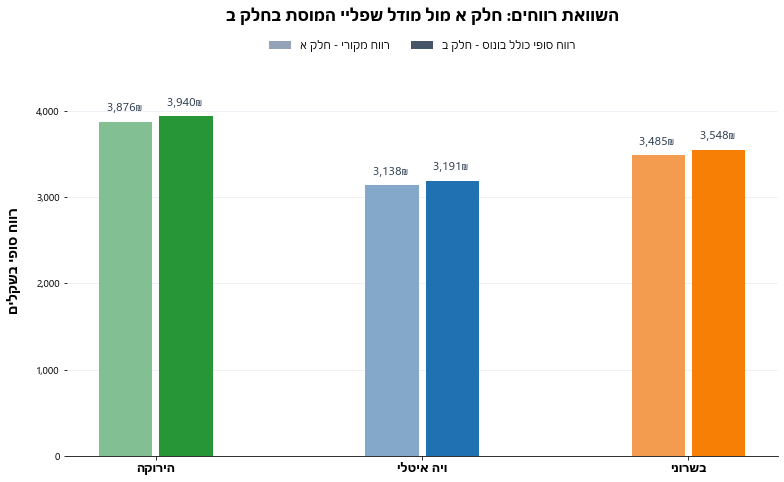

In [5]:
# pip install pulp matplotlib numpy pandas
import pulp as pl
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# =========================================================================
# ⚠️ שלב 1: הזנת נתוני הבסיס מחלק א'
# =========================================================================
part_a_profits = {
    "G": 3876,  # הירוקה
    "V": 3138,  # ויה איטלי
    "B": 3485   # בשרוני
}

# -------------------------------------------------------------------------
# שלב 2: נתוני התשתית (חלק ב')
# -------------------------------------------------------------------------
hours = [10, 11, 12, 13, 14, 15]
dishes = ["BH", "BS", "BP", "BSh", "BL", "VP", "VPst", "VR", "VN", "VZ", "GH", "GM", "GQ", "GI"]

profit = {"BH": 50, "BS": 110, "BP": 50, "BSh": 45, "BL": 45, "VP": 66, "VPst": 40, "VR": 65, "VN": 57, "VZ": 48, "GH": 66, "GM": 40, "GQ": 65, "GI": 57}
prep_time = {"BH": 13, "BS": 12, "BP": 10, "BSh": 10, "BL": 15, "VP": 14, "VPst": 7, "VR": 9, "VN": 9, "VZ": 8, "GH": 5, "GM": 7, "GQ": 7, "GI": 6}
demand = {"BH": 20, "BS": 10, "BP": 13, "BSh": 16, "BL": 7, "VP": 17, "VPst": 14, "VR": 11, "VN": 9, "VZ": 6, "GH": 17, "GM": 17, "GQ": 17, "GI": 17}

restaurants = {"G": "הירוקה", "V": "ויה איטלי", "B": "בשרוני"}

# -------------------------------------------------------------------------
# שלב 3: מנוע האופטימיזציה של שפליי
# -------------------------------------------------------------------------
def solve_for_coalition(selected_restaurants):
    model = pl.LpProblem("Optimization", pl.LpMaximize)
    X = pl.LpVariable.dicts("X", [(d, t) for d in dishes if d[0] in selected_restaurants for t in hours], lowBound=0, cat="Integer")
    Y = pl.LpVariable.dicts("Y", hours, lowBound=0, upBound=1, cat="Binary")
    model += pl.lpSum(profit[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants for t in hours) - pl.lpSum(60 * Y[t] for t in hours)
    for d in dishes:
        if d[0] in selected_restaurants: model += pl.lpSum(X[(d, t)] for t in hours) <= demand[d]
    for t in hours:
        model += pl.lpSum(prep_time[d] * X[(d, t)] for d in dishes if d[0] in selected_restaurants) <= 240 + 120 * Y[t]
    model.solve(pl.PULP_CBC_CMD(msg=0))
    return pl.value(model.objective)

players = ["G", "V", "B"]
coalitions = {}
for r in [1, 2, 3]:
    for subset in itertools.combinations(players, r):
        coalitions[tuple(sorted(subset))] = solve_for_coalition(list(subset))

def get_shapley(p):
    others = [o for o in players if o != p]
    val = (1/3) * coalitions[(p,)]
    for o in others: val += (1/6) * (coalitions[tuple(sorted([p, o]))] - coalitions[(o,)])
    val += (1/3) * (coalitions[("B", "G", "V")] - coalitions[tuple(sorted(others))])
    return val

raw_shapley = {p: get_shapley(p) for p in players}

# -------------------------------------------------------------------------
# שלב 4: מודל חלוקת הבונוס והחלפת משתנים
# -------------------------------------------------------------------------
total_part_a = sum(part_a_profits.values())
total_part_b = coalitions[("B", "G", "V")]
bonus_pool = total_part_b - total_part_a
sum_shapley = sum(raw_shapley.values())

final_rows = []
for p in players:
    bonus = (raw_shapley[p] / sum_shapley) * bonus_pool
    final_rows.append({
        "מסעדה": restaurants[p],
        "רווח מקורי (חלק א') - מובטח": part_a_profits[p],
        "אחוז תרומה תפעולית (מדד שפליי)": (bonus / bonus_pool) if bonus_pool > 0 else 0,
        "חלק יחסי בבונוס האינטגרציה": bonus,
        "רווח סופי כולל מוצע במתחם": part_a_profits[p] + bonus
    })

df_final = pd.DataFrame(final_rows)

# -------------------------------------------------------------------------
# שלב 5: הגדרות עיצוב גרפיות וצבעים
# -------------------------------------------------------------------------
plt.rcParams['font.family'] = 'Segoe UI'

# הגדרת פלטת הצבעים המדויקת מהתמונה
colors_part_a = ['#82bf93', '#83a8c9', '#f39c4f']  
colors_part_b = ['#279636', '#2071b1', '#f77f05']  

rest_names = [name[::-1] for name in df_final["מסעדה"].tolist()]

profits_part_a = df_final["רווח מקורי (חלק א') - מובטח"].tolist()
profits_part_b = df_final["רווח סופי כולל מוצע במתחם"].tolist()

width = 0.30  
positions = np.array([0, 1.5, 3.0])  

fig, ax = plt.subplots(figsize=(11, 6.8))

for i in range(len(rest_names)):
    pos_a = positions[i] - width/2 - 0.02  
    pos_b = positions[i] + width/2 + 0.02
    
    rect1 = ax.bar(pos_a, profits_part_a[i], width, color=colors_part_a[i], edgecolor='none')
    rect2 = ax.bar(pos_b, profits_part_b[i], width, color=colors_part_b[i], edgecolor='none')
    
    # תצוגת חלק א' (בסיס)
    ax.annotate(f'{int(round(profits_part_a[i])):,}' + ' ₪'[::-1],
                xy=(pos_a, profits_part_a[i]),
                xytext=(0, 8), textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='normal', color='#2c3e50')
                
    # תצוגת חלק ב' (סופי) - מעוגל מתמטית כלפי מעלה כדי למנוע את טעות ה-1 ש"ח
    ax.annotate(f'{int(round(profits_part_b[i])):,}' + ' ₪'[::-1],
                xy=(pos_b, profits_part_b[i]),
                xytext=(0, 8), textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='normal', color='#2c3e50')

# -------------------------------------------------------------------------
# עיצוב כותרות, צירים ומיקום המקרא
# -------------------------------------------------------------------------
ax.set_ylabel('רווח סופי בשקלים'[::-1], fontsize=13, fontweight='bold', labelpad=15)
ax.set_title('השוואת רווחים: חלק א מול מודל שפליי המוסת בחלק ב'[::-1], fontsize=16, fontweight='bold', pad=45)
ax.set_xticks(positions)
ax.set_xticklabels(rest_names, fontsize=12, fontweight='bold')

ax.set_ylim(0, max(profits_part_b) * 1.15)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#94a3b8', label='רווח מקורי - חלק א'[::-1]),
    Patch(facecolor='#475569', label='רווח סופי כולל בונוס - חלק ב'[::-1])
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.09), ncol=2, frameon=False)

formatter = ticker.StrMethodFormatter('{x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

ax.grid(axis='y', linestyle='-', alpha=0.7, color='#e2e8f0')
ax.set_axisbelow(True)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()